# Redes Convolucionales

Generado por la cátedra de Introducción a la Inteligencia Artificial de la  Licenciatura en Ciencias de la Computación - UNR

Autor: Nicolás Soncini

Integrantes: Gaston Davalos

In [1]:
from pathlib import Path
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
import numpy as np
import os
import pandas as pd

from datasets import load_dataset

# Tensorflow es un a librería o motor de machine learning
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
# chequeamos las versiones de las librerias y si tenemos GPU
# (dato de color: la traducción de "library" debería ser biblioteca, y no librería)
print(f"TensorFlow version: {tf.__version__}")
print(f"GPU Available: {tf.config.list_physical_devices('GPU')}")
print(f"Keras version: {keras.__version__}")

TensorFlow version: 2.20.0
GPU Available: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]
Keras version: 3.13.2


## Dataset

In [2]:
ds = load_dataset("uoft-cs/cifar10")
print(ds)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:112: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


README.md:   0%|          | 0.00/5.16k [00:00<?, ?B/s]

plain_text/train-00000-of-00001.parquet:   0%|          | 0.00/120M [00:00<?, ?B/s]

plain_text/test-00000-of-00001.parquet:   0%|          | 0.00/23.9M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/50000 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/10000 [00:00<?, ? examples/s]

DatasetDict({
    train: Dataset({
        features: ['img', 'label'],
        num_rows: 50000
    })
    test: Dataset({
        features: ['img', 'label'],
        num_rows: 10000
    })
})


In [3]:
LABELS = {
    0: "airplane",
    1: "automobile",
    2: "bird",
    3: "cat",
    4: "deer",
    5: "dog",
    6: "frog",
    7: "horse",
    8: "ship",
    9: "truck",
}

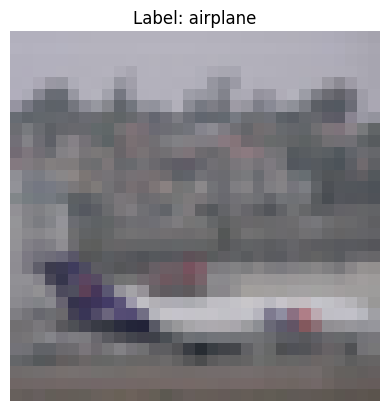

In [4]:
ds_train = ds['train']
ds_test = ds['test']

plt.imshow(ds_train[0]['img'])
plt.title(f'Label: {LABELS[ds_train[0]['label']]}')
plt.axis('off')
plt.show()

extraemos todo el dataset a memoria y normalizamos las imágenes al rango [0, 1]

In [5]:
x_train = np.array([np.array(element) for element in ds_train['img']])
y_train = np.array(ds_train['label'])
print(f"Training data shape: {x_train.shape}")
print(f"Training labels shape: {y_train.shape}")
x_train = x_train.astype('float32') / 255.0

Training data shape: (50000, 32, 32, 3)
Training labels shape: (50000,)


# Ejercicio 1. Visión por Computadora

Creo la red definida por el TP

In [ ]:
red_inicial = keras.Sequential([
    keras.Input(shape=(32, 32, 3), name='entrada'),

    layers.Conv2D(32, (3, 3), padding='same', activation='relu', name='conv2d_1'),

    layers.MaxPooling2D((2, 2), name='maxpool2d_1'),

    layers.Conv2D(64, (3, 3), padding='same', activation='relu', name='conv2d_2'),

    layers.Conv2D(64, (3, 3), padding='same', activation='relu', name='conv2d_3'),

    layers.MaxPooling2D((2, 2), name='maxpool2d_2'),

    layers.Conv2D(64, (3, 3), padding='same', activation='relu', name='conv2d_4'),

    layers.Conv2D(64, (3, 3), padding='same', activation='relu', name='conv2d_5'),

    layers.Flatten(name='flatten'),

    layers.Dense(64, activation='relu', name='dense_1'),

    layers.Dense(128, activation='relu', name='dense_2'),

    layers.Dense(128, activation='relu', name='dense_3'),

    layers.Dense(10, activation='softmax', name='salida')], name = 'red_inicial')

red_inicial.summary()

Model: "red_inicial"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_1 (Conv2D)               │ (None, 32, 32, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ maxpool2d_1 (MaxPooling2D)      │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 16, 16, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 16, 16, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ maxpool2d_2 (MaxPooling2D)      │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 8, 8, 64)       │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 8, 8, 64)       │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 4096)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │       262,208 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │         8,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ salida (Dense)                  │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 418,506 (1.60 MB)

 Trainable params: 418,506 (1.60 MB)

 Non-trainable params: 0 (0.00 B)

Defino los parámetros de la red

In [ ]:
optimizer = keras.optimizers.Adam(
    learning_rate=0.001
)

loss = keras.losses.CategoricalCrossentropy()

metrics = [
    keras.metrics.CategoricalAccuracy()
]

red_inicial.compile(
    optimizer=optimizer,
    loss=loss,
    metrics=metrics
)

Preparamos los datos

In [6]:
x_test = np.array([np.array(element) for element in ds_test['img']])
y_test = np.array(ds_test['label'])

x_test = x_test.astype('float32') / 255.0

num_classes = 10

y_train_onehot = keras.utils.to_categorical(y_train, num_classes)
y_test_onehot = keras.utils.to_categorical(y_test, num_classes)

# separamos un conjunto de validacion
x_train_processed, x_val_processed, y_train_processed, y_val_processed = \
    train_test_split(x_train, y_train_onehot, test_size=0.1, stratify=y_train)

# nos aseguramos que nos perdemos datos
assert(x_train_processed.shape[0] + x_val_processed.shape[0] == x_train.shape[0])
assert(y_train_processed.shape[0] + y_val_processed.shape[0] == y_train.shape[0])

Entrenamos la red

In [ ]:
print("\nStarting red_inicial training...")
history = red_inicial.fit(
    x_train_processed, y_train_processed,
    batch_size=16,
    epochs=50,
    validation_data=(x_val_processed, y_val_processed),
    verbose=1,
)
print("\nredi_inicial training completed!")


Starting red_inicial training...
Epoch 1/50
2813/2813 ━━━━━━━━━━━━━━━━━━━━ 21s 6ms/step - categorical_accuracy: 0.3944 - loss: 1.6236 - val_categorical_accuracy: 0.5140 - val_loss: 1.3575
Epoch 2/50
2813/2813 ━━━━━━━━━━━━━━━━━━━━ 13s 5ms/step - categorical_accuracy: 0.5736 - loss: 1.1892 - val_categorical_accuracy: 0.5908 - val_loss: 1.1444
Epoch 3/50
2813/2813 ━━━━━━━━━━━━━━━━━━━━ 13s 5ms/step - categorical_accuracy: 0.6458 - loss: 1.0025 - val_categorical_accuracy: 0.6442 - val_loss: 1.0150
Epoch 4/50
2813/2813 ━━━━━━━━━━━━━━━━━━━━ 13s 5ms/step - categorical_accuracy: 0.6909 - loss: 0.8863 - val_categorical_accuracy: 0.6702 - val_loss: 0.9568
Epoch 5/50
2813/2813 ━━━━━━━━━━━━━━━━━━━━ 13s 5ms/step - categorical_accuracy: 0.7225 - loss: 0.7889 - val_categorical_accuracy: 0.6414 - val_loss: 1.0242
Epoch 6/50
2813/2813 ━━━━━━━━━━━━━━━━━━━━ 13s 5ms/step - categorical_accuracy: 0.7486 - loss: 0.7220 - val_categorical_accuracy: 0.6862 - val_loss: 0.9398
Epoch 7/50
2813/2813 ━━━━━━━━━━━━━━━

In [ ]:
# guardamos la red
from google.colab import drive
drive.mount('/content/drive')
red_inicial.save('/content/drive/MyDrive/tp4_red_inicial.keras')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [7]:
# Generamos un codigo para graficar los resultados de la red
def plot_history_graphics(history, red, titulo):
    fig = plt.figure(figsize=(15, 5))

    # Plot training & validation accuracy
    plt.subplot(1, 2, 1)
    plt.plot(history.history['categorical_accuracy'], label='Training Cat. Accuracy')
    plt.plot(history.history['val_categorical_accuracy'], label='Validation Cat. Accuracy')
    plt.title('Model Cat. Accuracy')
    plt.xlabel('Epoch')
    plt.ylabel('Cat. Accuracy')
    plt.legend()
    plt.grid(True, alpha=0.3)

    # Plot training & validation loss
    plt.subplot(1, 2, 2)
    plt.plot(history.history['loss'], label='Training Loss')
    plt.plot(history.history['val_loss'], label='Validation Loss')
    plt.title('Model Loss')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.legend()
    plt.grid(True, alpha=0.3)

    fig.suptitle(titulo, fontsize=16, fontweight='bold')
    plt.tight_layout(rect=[0, 0, 1, 0.95])

    plt.show()

    # Print final training results
    print("Resultados finales entrenamiento:")
    print(f"Training Accuracy: {history.history['categorical_accuracy'][-1]:.4f}")
    print(f"Validation Accuracy: {history.history['val_categorical_accuracy'][-1]:.4f}")
    print(f"Training Loss: {history.history['loss'][-1]:.4f}")
    print(f"Validation Loss: {history.history['val_loss'][-1]:.4f}")
    print("")
    print(f"Best Validation Accuracy: {max(history.history['val_categorical_accuracy']):.4f}")
    print(f"Best Validation Loss: {min(history.history['val_loss']):.4f}")

def imprimir_test(red, x_test, y_test):
    # Imprimimos el resultado final para test
    cnn_predictions = red.predict(x_test, batch_size=32, verbose=1)
    cnn_predicted_classes = np.argmax(cnn_predictions, axis=1)

    cnn_correct_predictions = np.sum(cnn_predicted_classes == y_test)
    cnn_accuracy = cnn_correct_predictions / len(y_test)
    cnn_error_rate = 1 - cnn_accuracy

    print(f"\nCNN Results:")
    print(f"Correct predictions: {cnn_correct_predictions}/{len(y_test)}")
    print(f"Accuracy: {cnn_accuracy:.4f} ({cnn_accuracy*100:.2f}%)")
    print(f"Error Rate: {cnn_error_rate:.4f} ({cnn_error_rate*100:.2f}%)")

Graficamos los resultados de la red

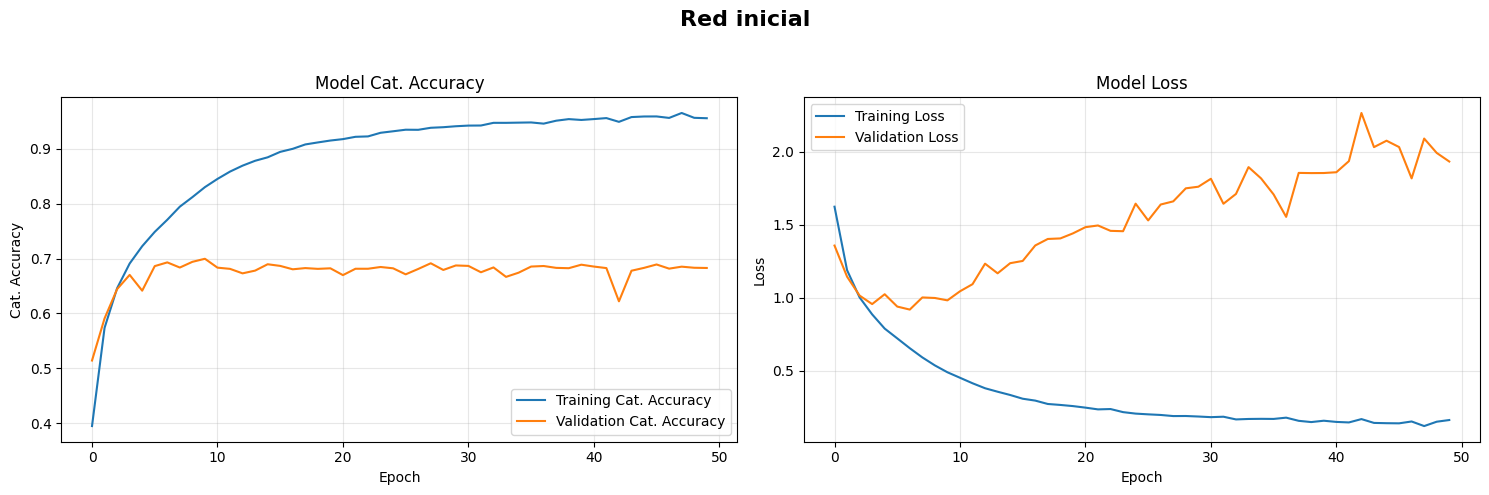

Resultados finales entrenamiento:
Training Accuracy: 0.9560
Validation Accuracy: 0.6828
Training Loss: 0.1628
Validation Loss: 1.9331

Best Validation Accuracy: 0.6996
Best Validation Loss: 0.9191


In [ ]:
plot_history_graphics(history, red_inicial, "Red inicial")

In [ ]:
imprimir_test(red_inicial, x_test, y_test)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step

CNN Results:
Correct predictions: 6860/10000
Accuracy: 0.6860 (68.60%)
Error Rate: 0.3140 (31.40%)


#Modificaciones en la arquitectura de la red

1. Modificacion:
Para este caso, voy a modificar la arquitectura de la red para que no hayan capas de convoluciones consecutivas, en su lugar, para cada capa de convolucion la sigue una capa de pooling


In [ ]:
# definimos la arquitectura de la red
red_mod1 = keras.Sequential([
    keras.Input(shape=(32, 32, 3), name='entrada'),

    layers.Conv2D(32, (3, 3), padding='same', activation='relu', name='conv2d_1'),

    layers.MaxPooling2D((2, 2), name='maxpool2d_1'),

    layers.Conv2D(64, (3, 3), padding='same', activation='relu', name='conv2d_2'),

    layers.MaxPooling2D((2, 2), name='maxpool2d_2'),

    layers.Conv2D(64, (3, 3), padding='same', activation='relu', name='conv2d_3'),

    layers.MaxPooling2D((2, 2), name='maxpool2d_3'),

    layers.Flatten(name='flatten'),

    layers.Dense(64, activation='relu', name='dense_1'),

    layers.Dense(128, activation='relu', name='dense_2'),

    layers.Dense(128, activation='relu', name='dense_3'),

    layers.Dense(10, activation='softmax', name='salida')], name = 'red_mod1')

red_mod1.summary()

# defino los parametros de la red
optimizer = keras.optimizers.Adam(learning_rate=0.001)

loss = keras.losses.CategoricalCrossentropy()

metrics = [keras.metrics.CategoricalAccuracy()]

red_mod1.compile(
    optimizer=optimizer,
    loss=loss,
    metrics=metrics
)

Model: "red_mod1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_1 (Conv2D)               │ (None, 32, 32, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ maxpool2d_1 (MaxPooling2D)      │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 16, 16, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ maxpool2d_2 (MaxPooling2D)      │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 8, 8, 64)       │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ maxpool2d_3 (MaxPooling2D)      │ (None, 4, 4, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 1024)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │        65,600 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │         8,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ salida (Dense)                  │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 148,042 (578.29 KB)

 Trainable params: 148,042 (578.29 KB)

 Non-trainable params: 0 (0.00 B)

Entrenamos la red

In [ ]:
print("\nStarting red_mod1 training...")
history = red_mod1.fit(
    x_train_processed, y_train_processed,
    batch_size=16,
    epochs=50,
    validation_data=(x_val_processed, y_val_processed),
    verbose=1,
)
print("\nred_mod1 training completed!")


Starting red_mod1 training...
Epoch 1/50
2813/2813 ━━━━━━━━━━━━━━━━━━━━ 21s 6ms/step - categorical_accuracy: 0.4494 - loss: 1.4998 - val_categorical_accuracy: 0.5650 - val_loss: 1.1936
Epoch 2/50
2813/2813 ━━━━━━━━━━━━━━━━━━━━ 13s 5ms/step - categorical_accuracy: 0.6115 - loss: 1.0919 - val_categorical_accuracy: 0.6280 - val_loss: 1.0360
Epoch 3/50
2813/2813 ━━━━━━━━━━━━━━━━━━━━ 14s 5ms/step - categorical_accuracy: 0.6702 - loss: 0.9379 - val_categorical_accuracy: 0.6578 - val_loss: 0.9724
Epoch 4/50
2813/2813 ━━━━━━━━━━━━━━━━━━━━ 12s 4ms/step - categorical_accuracy: 0.7027 - loss: 0.8496 - val_categorical_accuracy: 0.6802 - val_loss: 0.9198
Epoch 5/50
2813/2813 ━━━━━━━━━━━━━━━━━━━━ 11s 4ms/step - categorical_accuracy: 0.7316 - loss: 0.7749 - val_categorical_accuracy: 0.6694 - val_loss: 0.9539
Epoch 6/50
2813/2813 ━━━━━━━━━━━━━━━━━━━━ 21s 4ms/step - categorical_accuracy: 0.7469 - loss: 0.7205 - val_categorical_accuracy: 0.7036 - val_loss: 0.8644
Epoch 7/50
2813/2813 ━━━━━━━━━━━━━━━━━━

In [ ]:
# guardamos la red
from google.colab import drive
drive.mount('/content/drive')
red_mod1.save('/content/drive/MyDrive/tp4_red_mod1.keras')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


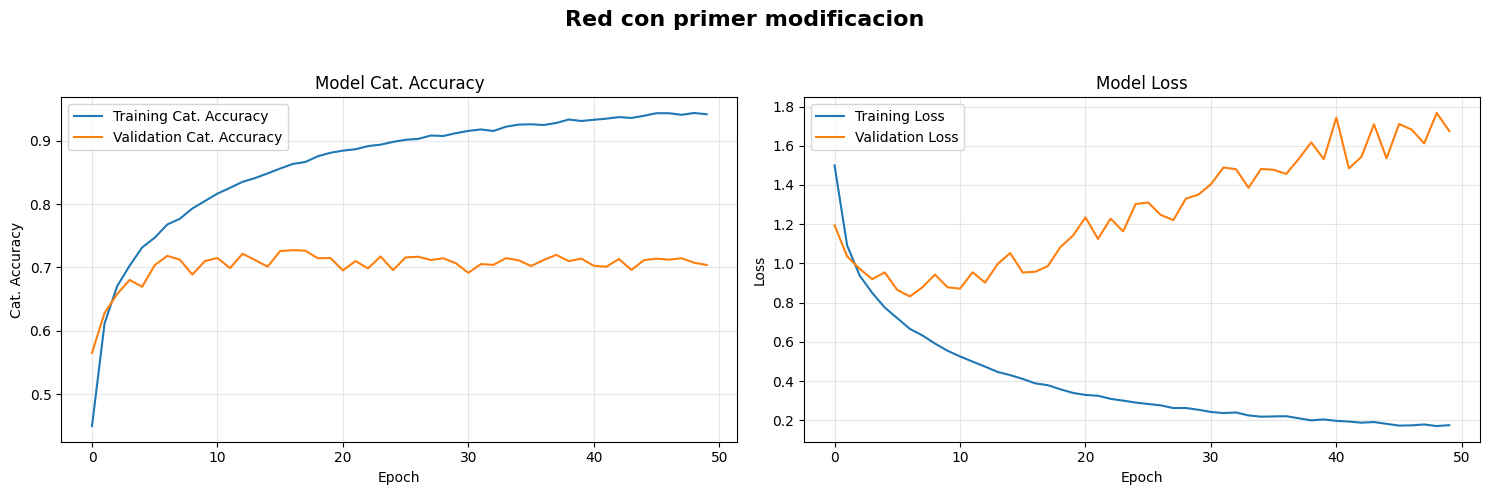

Resultados finales entrenamiento:
Training Accuracy: 0.9418
Validation Accuracy: 0.7038
Training Loss: 0.1748
Validation Loss: 1.6754

Best Validation Accuracy: 0.7272
Best Validation Loss: 0.8316


In [ ]:
plot_history_graphics(history, red_mod1, "Red con primer modificacion")

In [ ]:
imprimir_test(red_mod1, x_test, y_test)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step

CNN Results:
Correct predictions: 7047/10000
Accuracy: 0.7047 (70.47%)
Error Rate: 0.2953 (29.53%)


**Conclusion**: Vemos claramente que la red mejoro, esto puede ser por lo visto en clase que cuando aplicamos una capa de convolusion aplicamos el filtro en toda la imagen pero por pedazos y la red aprende patrones sencillos, luego con la capa de pooling usa esos patrones sencillos y aprende patrones mas complejos y de esa forma aprende la red. Por lo cual, como en la arquitectura original de la red tenia capas de convolusion seguidas sin pooling antes de flatten entonces no se esta aprovechando esta logica de ir de lo simple a lo complejo. A su vez, en la arquitectura original al no tener un pooling antes del flatten tenemos muchos pesos, ya que con el pooling podriamos reducir el tamano de la imagen y con ello la cantidad de pesos, al tener mayor cantidad de pesos podemos caer en overfitting.



2. Modificacion:
Para este caso, voy a cambiar el orden de las capas densas

In [ ]:
# definimos la arquitectura de la red
red_mod2 = keras.Sequential([
    keras.Input(shape=(32, 32, 3), name='entrada'),

    layers.Conv2D(32, (3, 3), padding='same', activation='relu', name='conv2d_1'),

    layers.MaxPooling2D((2, 2), name='maxpool2d_1'),

    layers.Conv2D(64, (3, 3), padding='same', activation='relu', name='conv2d_2'),

    layers.Conv2D(64, (3, 3), padding='same', activation='relu', name='conv2d_3'),

    layers.MaxPooling2D((2, 2), name='maxpool2d_2'),

    layers.Conv2D(64, (3, 3), padding='same', activation='relu', name='conv2d_4'),

    layers.Conv2D(64, (3, 3), padding='same', activation='relu', name='conv2d_5'),

    layers.Flatten(name='flatten'),

    layers.Dense(128, activation='relu', name='dense_1'),

    layers.Dense(128, activation='relu', name='dense_2'),

    layers.Dense(64, activation='relu', name='dense_3'),

    layers.Dense(10, activation='softmax', name='salida')], name = 'red_mod2')

red_mod2.summary()

# defino los parametros de la red
optimizer = keras.optimizers.Adam(learning_rate=0.001)

loss = keras.losses.CategoricalCrossentropy()

metrics = [keras.metrics.CategoricalAccuracy()]

red_mod2.compile(
    optimizer=optimizer,
    loss=loss,
    metrics=metrics
)

Model: "red_mod2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_1 (Conv2D)               │ (None, 32, 32, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ maxpool2d_1 (MaxPooling2D)      │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 16, 16, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 16, 16, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ maxpool2d_2 (MaxPooling2D)      │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 8, 8, 64)       │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 8, 8, 64)       │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 4096)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │       524,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ salida (Dense)                  │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 680,010 (2.59 MB)

 Trainable params: 680,010 (2.59 MB)

 Non-trainable params: 0 (0.00 B)

Entrenamos la red

In [ ]:
print("\nStarting red_mod2 training...")
history = red_mod2.fit(
    x_train_processed, y_train_processed,
    batch_size=16,
    epochs=50,
    validation_data=(x_val_processed, y_val_processed),
    verbose=1,
)
print("\nred_mod2 training completed!")


Starting red_mod2 training...
Epoch 1/50
2813/2813 ━━━━━━━━━━━━━━━━━━━━ 21s 6ms/step - categorical_accuracy: 0.4016 - loss: 1.6148 - val_categorical_accuracy: 0.5272 - val_loss: 1.2904
Epoch 2/50
2813/2813 ━━━━━━━━━━━━━━━━━━━━ 14s 5ms/step - categorical_accuracy: 0.5790 - loss: 1.1764 - val_categorical_accuracy: 0.6048 - val_loss: 1.1298
Epoch 3/50
2813/2813 ━━━━━━━━━━━━━━━━━━━━ 17s 6ms/step - categorical_accuracy: 0.6449 - loss: 0.9994 - val_categorical_accuracy: 0.6414 - val_loss: 1.0036
Epoch 4/50
2813/2813 ━━━━━━━━━━━━━━━━━━━━ 17s 6ms/step - categorical_accuracy: 0.6950 - loss: 0.8708 - val_categorical_accuracy: 0.6686 - val_loss: 0.9431
Epoch 5/50
2813/2813 ━━━━━━━━━━━━━━━━━━━━ 14s 5ms/step - categorical_accuracy: 0.7302 - loss: 0.7691 - val_categorical_accuracy: 0.6744 - val_loss: 0.9567
Epoch 6/50
2813/2813 ━━━━━━━━━━━━━━━━━━━━ 14s 5ms/step - categorical_accuracy: 0.7565 - loss: 0.6868 - val_categorical_accuracy: 0.6840 - val_loss: 0.9505
Epoch 7/50
2813/2813 ━━━━━━━━━━━━━━━━━━

In [ ]:
# guardamos la red
from google.colab import drive
drive.mount('/content/drive')
red_mod2.save('/content/drive/MyDrive/tp4_red_mod2.keras')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


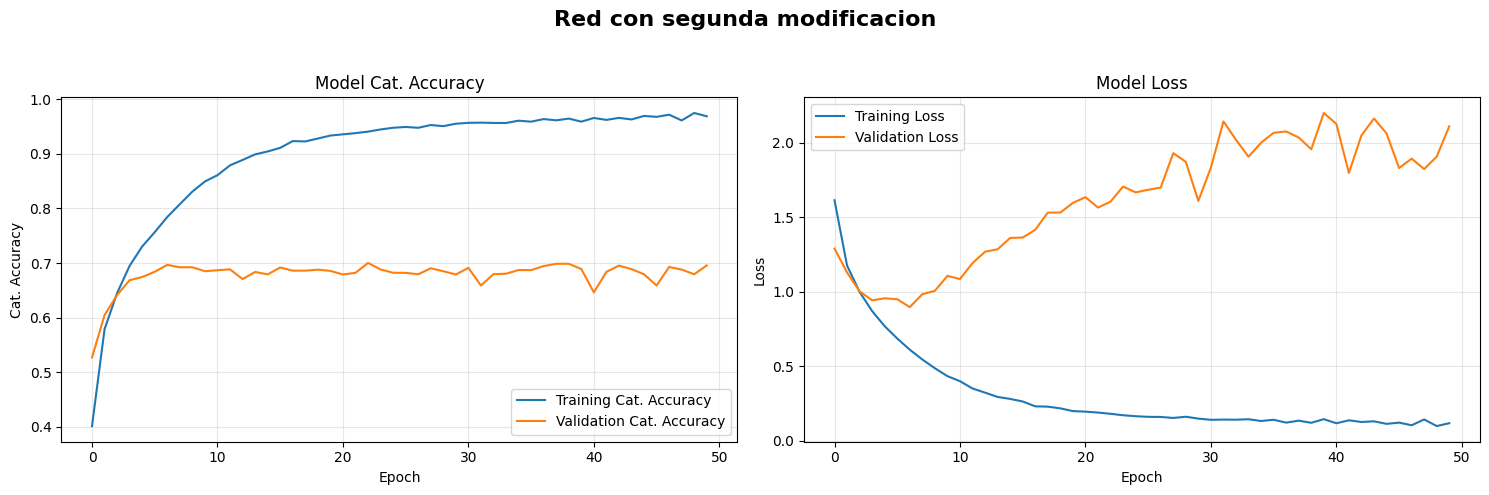

Resultados finales entrenamiento:
Training Accuracy: 0.9685
Validation Accuracy: 0.6956
Training Loss: 0.1183
Validation Loss: 2.1114

Best Validation Accuracy: 0.7002
Best Validation Loss: 0.8973


In [ ]:
plot_history_graphics(history, red_mod2, "Red con segunda modificacion")

In [ ]:
imprimir_test(red_mod2, x_test, y_test)

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step

CNN Results:
Correct predictions: 6873/10000
Accuracy: 0.6873 (68.73%)
Error Rate: 0.3127 (31.27%)


**Conclusion**: Esta modificacion la hice porque como en la ultima capa antes de flatten tengo mayor informacion tiene sentido ir condensando la misma en las capas bajando el numero de neuronas de las mismas en lugar de empezar con menos neuronas y luego aumentarlas. Voy comprimiendo la informacion en lugar de expandirla, no tiene sentido comprimir la informacion para luego volver a expandirla.

3. Modificacion: voy a agregar mas capas de convolucion con mas filtros antes de cada pooling y las capas densas van a disminuir en nodos


In [ ]:
# definimos la arquitectura de la red
red_mod3 = keras.Sequential([
    keras.Input(shape=(32, 32, 3), name='entrada'),

    layers.Conv2D(32, (3, 3), padding='same', activation='relu', name='conv2d_1'),

    layers.Conv2D(32, (3, 3), padding='same', activation='relu', name='conv2d_2'),

    layers.MaxPooling2D((2, 2), name='maxpool2d_1'),

    layers.Conv2D(64, (3, 3), padding='same', activation='relu', name='conv2d_3'),

    layers.Conv2D(64, (3, 3), padding='same', activation='relu', name='conv2d_4'),

    layers.MaxPooling2D((2, 2), name='maxpool2d_2'),

    layers.Conv2D(64, (3, 3), padding='same', activation='relu', name='conv2d_5'),

    layers.Conv2D(64, (3, 3), padding='same', activation='relu', name='conv2d_6'),

    layers.MaxPooling2D((2, 2), name='maxpool2d_3'),

    layers.Flatten(name='flatten'),

    layers.Dense(128, activation='relu', name='dense_1'),

    layers.Dense(64, activation='relu', name='dense_2'),

    layers.Dense(10, activation='softmax', name='salida')], name = 'red_mod3')

red_mod3.summary()

# defino los parametros de la red
optimizer = keras.optimizers.Adam(learning_rate=0.001)

loss = keras.losses.CategoricalCrossentropy()

metrics = [keras.metrics.CategoricalAccuracy()]

red_mod3.compile(
    optimizer=optimizer,
    loss=loss,
    metrics=metrics
)

Model: "red_mod3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_1 (Conv2D)               │ (None, 32, 32, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 32, 32, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ maxpool2d_1 (MaxPooling2D)      │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 16, 16, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 16, 16, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ maxpool2d_2 (MaxPooling2D)      │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 8, 8, 64)       │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 8, 8, 64)       │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ maxpool2d_3 (MaxPooling2D)      │ (None, 4, 4, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 1024)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │       131,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ salida (Dense)                  │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 279,530 (1.07 MB)

 Trainable params: 279,530 (1.07 MB)

 Non-trainable params: 0 (0.00 B)

Entrenamos la red

In [ ]:
print("\nStarting red_mod3 training...")
history = red_mod3.fit(
    x_train_processed, y_train_processed,
    batch_size=16,
    epochs=50,
    validation_data=(x_val_processed, y_val_processed),
    verbose=1,
)
print("\nred_mod3 training completed!")


Starting red_mod3 training...
Epoch 1/50
2813/2813 ━━━━━━━━━━━━━━━━━━━━ 21s 6ms/step - categorical_accuracy: 0.4185 - loss: 1.5715 - val_categorical_accuracy: 0.5362 - val_loss: 1.2570
Epoch 2/50
2813/2813 ━━━━━━━━━━━━━━━━━━━━ 13s 5ms/step - categorical_accuracy: 0.6071 - loss: 1.0980 - val_categorical_accuracy: 0.6478 - val_loss: 0.9736
Epoch 3/50
2813/2813 ━━━━━━━━━━━━━━━━━━━━ 15s 5ms/step - categorical_accuracy: 0.6789 - loss: 0.9073 - val_categorical_accuracy: 0.6754 - val_loss: 0.8973
Epoch 4/50
2813/2813 ━━━━━━━━━━━━━━━━━━━━ 15s 5ms/step - categorical_accuracy: 0.7246 - loss: 0.7847 - val_categorical_accuracy: 0.6776 - val_loss: 0.9179
Epoch 5/50
2813/2813 ━━━━━━━━━━━━━━━━━━━━ 16s 6ms/step - categorical_accuracy: 0.7556 - loss: 0.6928 - val_categorical_accuracy: 0.7126 - val_loss: 0.8373
Epoch 6/50
2813/2813 ━━━━━━━━━━━━━━━━━━━━ 15s 5ms/step - categorical_accuracy: 0.7806 - loss: 0.6264 - val_categorical_accuracy: 0.7332 - val_loss: 0.7700
Epoch 7/50
2813/2813 ━━━━━━━━━━━━━━━━━━

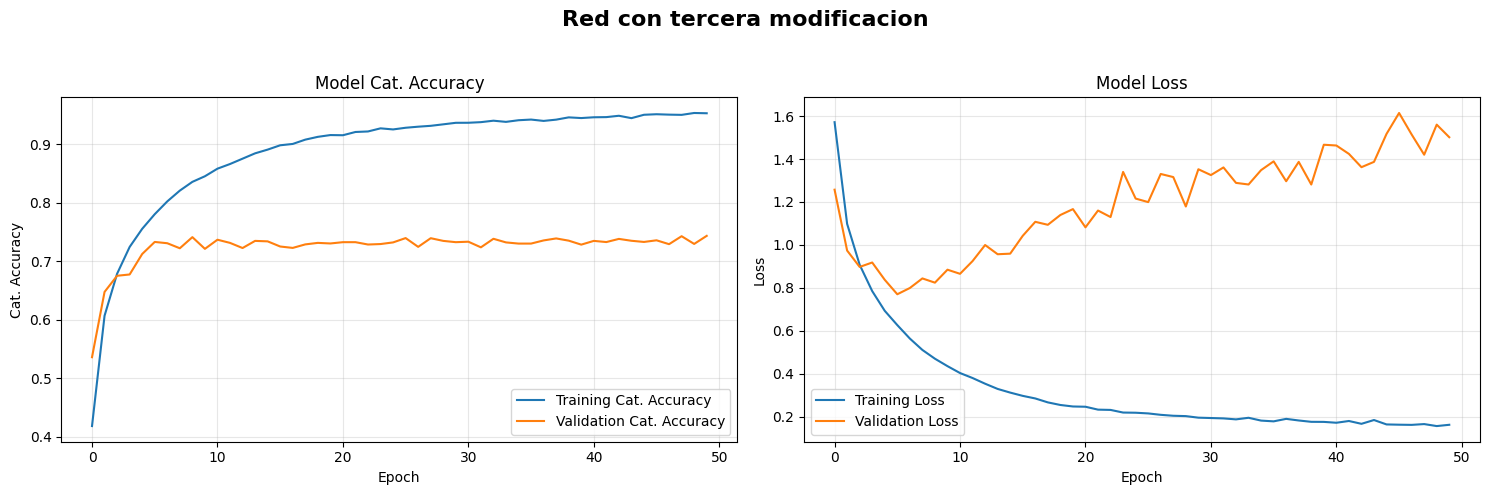

Resultados finales entrenamiento:
Training Accuracy: 0.9531
Validation Accuracy: 0.7436
Training Loss: 0.1620
Validation Loss: 1.5014

Best Validation Accuracy: 0.7436
Best Validation Loss: 0.7700


In [ ]:
plot_history_graphics(history, red_mod3, "Red con tercera modificacion")

In [ ]:
imprimir_test(red_mod3, x_test, y_test)

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step

CNN Results:
Correct predictions: 7366/10000
Accuracy: 0.7366 (73.66%)
Error Rate: 0.2634 (26.34%)


**Conclusion**: La modificacion de aumentar la cantidad de filtros es que como vamos pasando de patrones simples a complejos la red va a necesitar una mayor cantidad de filtros para poder aprender estos patrones mas complejos.Tambien cambiamos el orden de las capas densas por la misma razon que en el caso anterior. Tambien nos quedamos con solo 2 capas densas y no 3 para reducir el overfitting. Vemos que usando esta configuracion de la red llegamos una mejora mayor al 3%.

# Ejercicio 2. Dropout

Para aplicar Dropout me quedo con la red de la primera modificacion

In [ ]:
#funcion para entrenar red con el dropout despues de la ultima capa de convolucion
def red_dropout1(p, nombre):
  red = keras.Sequential([
    keras.Input(shape=(32, 32, 3), name='entrada'),

    layers.Conv2D(32, (3, 3), padding='same', activation='relu', name='conv2d_1'),

    layers.Conv2D(32, (3, 3), padding='same', activation='relu', name='conv2d_2'),

    layers.MaxPooling2D((2, 2), name='maxpool2d_1'),

    layers.Conv2D(64, (3, 3), padding='same', activation='relu', name='conv2d_3'),

    layers.Conv2D(64, (3, 3), padding='same', activation='relu', name='conv2d_4'),

    layers.MaxPooling2D((2, 2), name='maxpool2d_2'),

    layers.Conv2D(64, (3, 3), padding='same', activation='relu', name='conv2d_5'),

    layers.Conv2D(64, (3, 3), padding='same', activation='relu', name='conv2d_6'),

    layers.MaxPooling2D((2, 2), name='maxpool2d_3'),

    layers.Dropout(p),

    layers.Flatten(name='flatten'),

    layers.Dense(128, activation='relu', name='dense_1'),

    layers.Dense(64, activation='relu', name='dense_2'),

    layers.Dense(10, activation='softmax', name='salida')], name = nombre)

  red.summary()

  optimizer = keras.optimizers.Adam(learning_rate=0.001)

  loss = keras.losses.CategoricalCrossentropy()

  metrics = [keras.metrics.CategoricalAccuracy()]

  red.compile(
    optimizer=optimizer,
    loss=loss,
    metrics=metrics
  )

  return red

In [10]:
#funcion para entrenar red con las dos capas de dropout
def red_dropout2(p, nombre):
  red = keras.Sequential([
    keras.Input(shape=(32, 32, 3), name='entrada'),

    layers.Conv2D(32, (3, 3), padding='same', activation='relu', name='conv2d_1'),

    layers.Conv2D(32, (3, 3), padding='same', activation='relu', name='conv2d_2'),

    layers.MaxPooling2D((2, 2), name='maxpool2d_1'),

    layers.Conv2D(64, (3, 3), padding='same', activation='relu', name='conv2d_3'),

    layers.Conv2D(64, (3, 3), padding='same', activation='relu', name='conv2d_4'),

    layers.MaxPooling2D((2, 2), name='maxpool2d_2'),

    layers.Conv2D(64, (3, 3), padding='same', activation='relu', name='conv2d_5'),

    layers.Conv2D(64, (3, 3), padding='same', activation='relu', name='conv2d_6'),

    layers.MaxPooling2D((2, 2), name='maxpool2d_3'),

    layers.Dropout(p),

    layers.Flatten(name='flatten'),

    layers.Dense(128, activation='relu', name='dense_1'),

    layers.Dropout(p),

    layers.Dense(64, activation='relu', name='dense_2'),

    layers.Dense(10, activation='softmax', name='salida')], name = nombre)

  red.summary()

  optimizer = keras.optimizers.Adam(learning_rate=0.001)

  loss = keras.losses.CategoricalCrossentropy()

  metrics = [keras.metrics.CategoricalAccuracy()]

  red.compile(
    optimizer=optimizer,
    loss=loss,
    metrics=metrics
  )

  return red

In [11]:
# funcion para entrenar las redes
def entrenar_red_dropout(red, nombre):
  print(f"\nStarting {nombre} training...")
  history = red.fit(
      x_train_processed, y_train_processed,
      batch_size=16,
      epochs=100,
      validation_data=(x_val_processed, y_val_processed),
      verbose=1,
  )
  print(f"\n{nombre} training completed!")
  return history

Entrenamos las redes

In [ ]:
# definimos las redes
red_drop1_1 = red_dropout1(0.2, "red_dropout1_02")

red_drop1_2 = red_dropout1(0.5, "red_dropout1_05")

red_drop2_1 = red_dropout2(0.2, "red_dropout2_02")

red_drop2_2 = red_dropout2(0.5, "red_dropout2_05")

Model: "red_dropout1_02"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_1 (Conv2D)               │ (None, 32, 32, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 32, 32, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ maxpool2d_1 (MaxPooling2D)      │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 16, 16, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 16, 16, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ maxpool2d_2 (MaxPooling2D)      │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 8, 8, 64)       │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 8, 8, 64)       │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ maxpool2d_3 (MaxPooling2D)      │ (None, 4, 4, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 4, 4, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 1024)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │       131,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ salida (Dense)                  │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 279,530 (1.07 MB)

 Trainable params: 279,530 (1.07 MB)

 Non-trainable params: 0 (0.00 B)

...

Model: "red_dropout2_05"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_1 (Conv2D)               │ (None, 32, 32, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 32, 32, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ maxpool2d_1 (MaxPooling2D)      │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 16, 16, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 16, 16, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ maxpool2d_2 (MaxPooling2D)      │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 8, 8, 64)       │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 8, 8, 64)       │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ maxpool2d_3 (MaxPooling2D)      │ (None, 4, 4, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_10 (Dropout)            │ (None, 4, 4, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 1024)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │       131,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_11 (Dropout)            │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ salida (Dense)                  │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 279,530 (1.07 MB)

 Trainable params: 279,530 (1.07 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
# entrenamos las redes
history1 = entrenar_red_dropout(red_drop1_1, "red_dropout1_02")

from google.colab import drive
drive.mount('/content/drive')
red_drop1_1.save('/content/drive/MyDrive/tp4_red_drop1_02.keras')


Starting red_dropout1_02 training...
Epoch 1/100
2813/2813 ━━━━━━━━━━━━━━━━━━━━ 25s 7ms/step - categorical_accuracy: 0.4225 - loss: 1.5587 - val_categorical_accuracy: 0.5702 - val_loss: 1.1921
Epoch 2/100
2813/2813 ━━━━━━━━━━━━━━━━━━━━ 13s 5ms/step - categorical_accuracy: 0.6058 - loss: 1.1047 - val_categorical_accuracy: 0.6520 - val_loss: 0.9659
Epoch 3/100
2813/2813 ━━━━━━━━━━━━━━━━━━━━ 13s 5ms/step - categorical_accuracy: 0.6708 - loss: 0.9322 - val_categorical_accuracy: 0.6686 - val_loss: 0.9124
Epoch 4/100
2813/2813 ━━━━━━━━━━━━━━━━━━━━ 21s 5ms/step - categorical_accuracy: 0.7077 - loss: 0.8308 - val_categorical_accuracy: 0.6900 - val_loss: 0.8874
Epoch 5/100
2813/2813 ━━━━━━━━━━━━━━━━━━━━ 13s 5ms/step - categorical_accuracy: 0.7346 - loss: 0.7603 - val_categorical_accuracy: 0.7160 - val_loss: 0.8044
Epoch 6/100
2813/2813 ━━━━━━━━━━━━━━━━━━━━ 13s 5ms/step - categorical_accuracy: 0.7531 - loss: 0.6975 - val_categorical_accuracy: 0.7018 - val_loss: 0.8668
Epoch 7/100
2813/2813 ━━━━

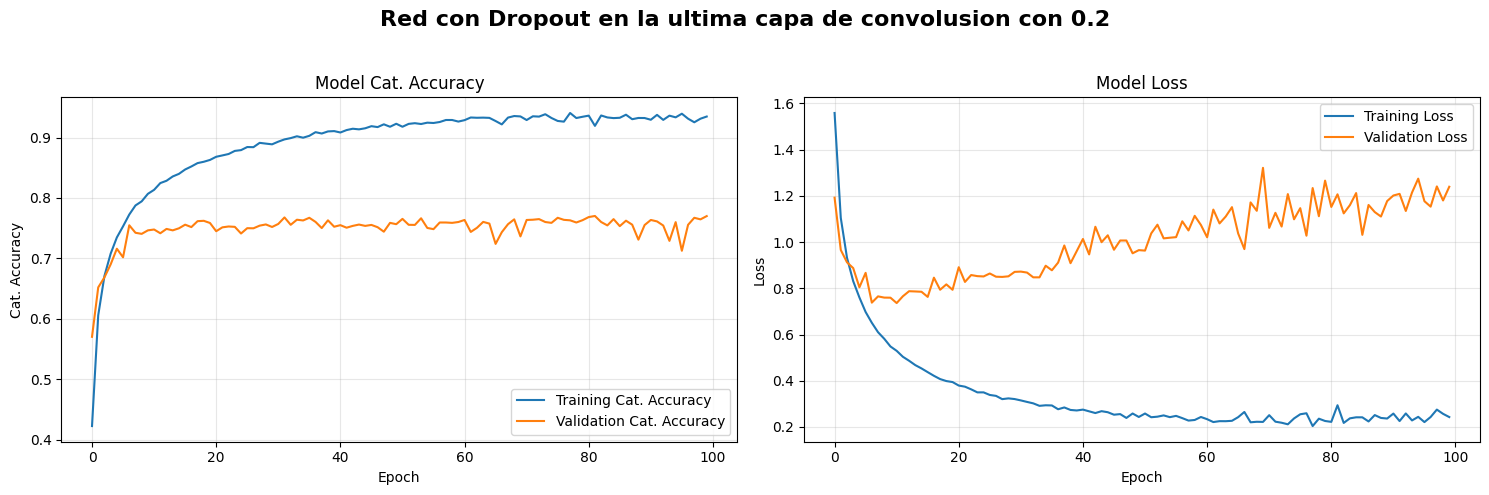

Resultados finales entrenamiento:
Training Accuracy: 0.9348
Validation Accuracy: 0.7700
Training Loss: 0.2427
Validation Loss: 1.2394

Best Validation Accuracy: 0.7702
Best Validation Loss: 0.7361


In [ ]:
plot_history_graphics(history1, red_drop1_1, "Red con Dropout en la ultima capa de convolusion con 0.2")

In [ ]:
imprimir_test(red_drop1_1, x_test, y_test)

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step

CNN Results:
Correct predictions: 7651/10000
Accuracy: 0.7651 (76.51%)
Error Rate: 0.2349 (23.49%)


In [ ]:
history2 = entrenar_red_dropout(red_drop1_2, "red_dropout1_02")
red_drop1_2.save('/content/drive/MyDrive/tp4_red_drop1_05.keras')


Starting red_dropout1_02 training...
Epoch 1/100
2813/2813 ━━━━━━━━━━━━━━━━━━━━ 22s 6ms/step - categorical_accuracy: 0.3967 - loss: 1.6230 - val_categorical_accuracy: 0.5372 - val_loss: 1.2565
Epoch 2/100
2813/2813 ━━━━━━━━━━━━━━━━━━━━ 13s 4ms/step - categorical_accuracy: 0.5588 - loss: 1.2212 - val_categorical_accuracy: 0.5940 - val_loss: 1.0904
Epoch 3/100
2813/2813 ━━━━━━━━━━━━━━━━━━━━ 12s 4ms/step - categorical_accuracy: 0.6296 - loss: 1.0445 - val_categorical_accuracy: 0.6704 - val_loss: 0.9259
Epoch 4/100
2813/2813 ━━━━━━━━━━━━━━━━━━━━ 13s 4ms/step - categorical_accuracy: 0.6668 - loss: 0.9380 - val_categorical_accuracy: 0.7012 - val_loss: 0.8661
Epoch 5/100
2813/2813 ━━━━━━━━━━━━━━━━━━━━ 12s 4ms/step - categorical_accuracy: 0.6947 - loss: 0.8658 - val_categorical_accuracy: 0.7004 - val_loss: 0.8448
Epoch 6/100
2813/2813 ━━━━━━━━━━━━━━━━━━━━ 12s 4ms/step - categorical_accuracy: 0.7186 - loss: 0.8063 - val_categorical_accuracy: 0.7308 - val_loss: 0.7809
Epoch 7/100
2813/2813 ━━━━

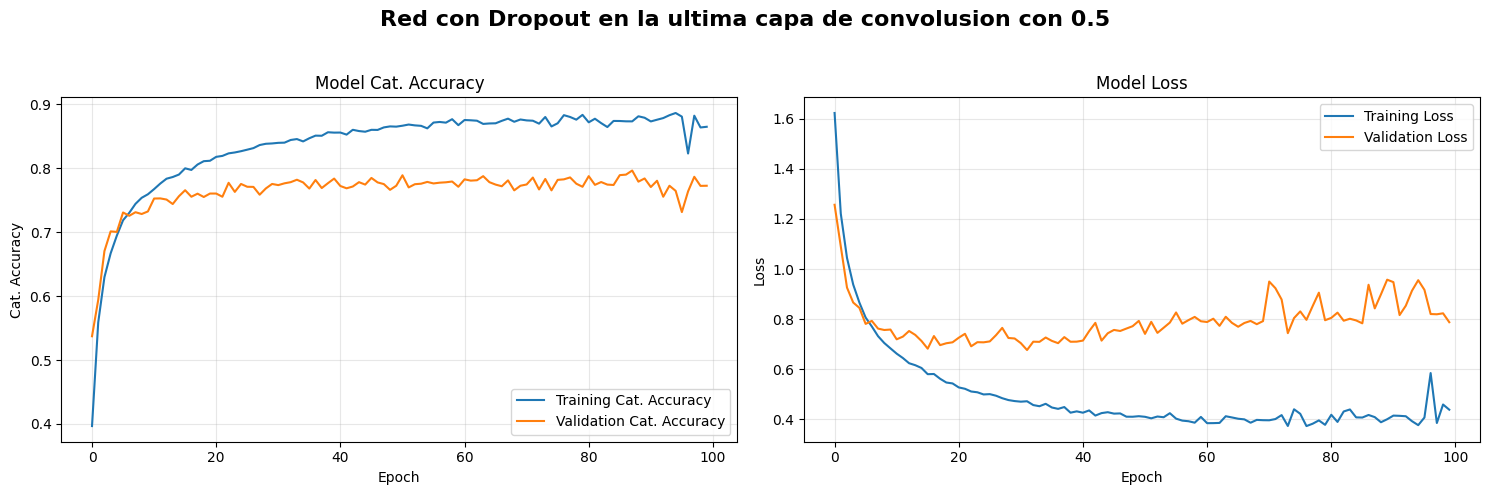

Resultados finales entrenamiento:
Training Accuracy: 0.8648
Validation Accuracy: 0.7726
Training Loss: 0.4382
Validation Loss: 0.7876

Best Validation Accuracy: 0.7964
Best Validation Loss: 0.6765


In [ ]:
plot_history_graphics(history2, red_drop1_2, "Red con Dropout en la ultima capa de convolusion con 0.5")

In [ ]:
imprimir_test(red_drop1_2, x_test, y_test)

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step

CNN Results:
Correct predictions: 7630/10000
Accuracy: 0.7630 (76.30%)
Error Rate: 0.2370 (23.70%)


In [ ]:
history3 = entrenar_red_dropout(red_drop2_1, "red_dropout2_02")
red_drop2_1.save('/content/drive/MyDrive/tp4_red_drop2_02.keras')

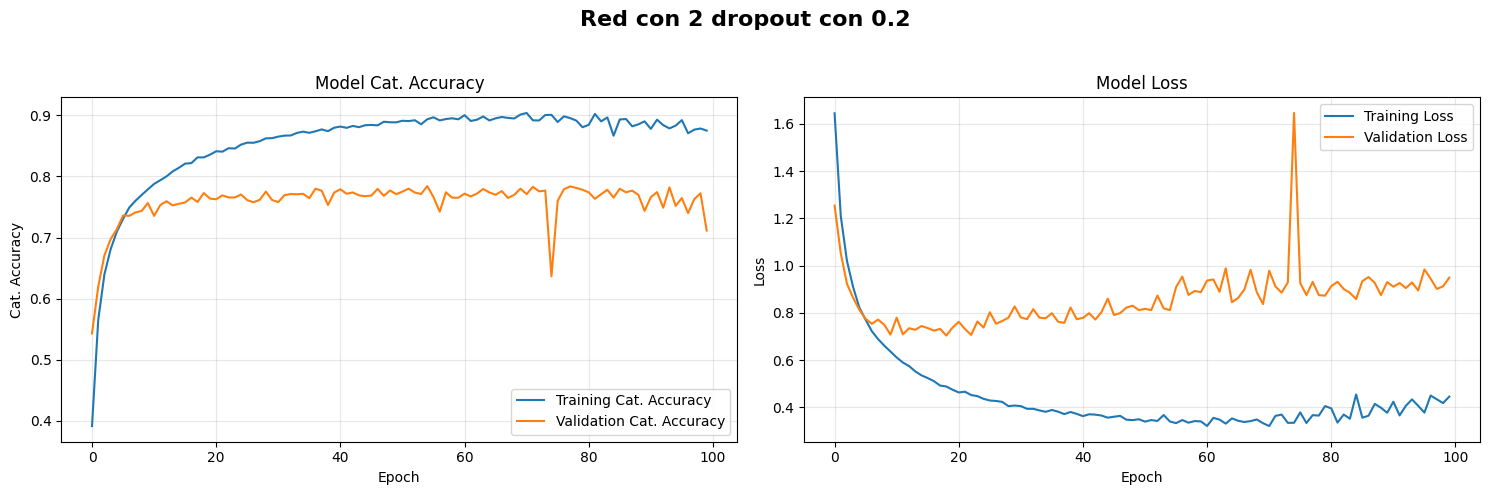

Resultados finales entrenamiento:
Training Accuracy: 0.8749
Validation Accuracy: 0.7114
Training Loss: 0.4460
Validation Loss: 0.9494

Best Validation Accuracy: 0.7842
Best Validation Loss: 0.7043


In [ ]:
plot_history_graphics(history3, red_drop2_1, "Red con 2 dropout con 0.2")

In [ ]:
imprimir_test(red_drop2_1, x_test, y_test)

313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step

CNN Results:
Correct predictions: 7062/10000
Accuracy: 0.7062 (70.62%)
Error Rate: 0.2938 (29.38%)


In [ ]:
history4 = entrenar_red_dropout(red_drop2_2, "red_dropout2_05")
red_drop2_2.save('/content/drive/MyDrive/tp4_red_drop2_05.keras')


Starting red_dropout2_05 training...
Epoch 1/100
2813/2813 ━━━━━━━━━━━━━━━━━━━━ 23s 6ms/step - categorical_accuracy: 0.3389 - loss: 1.7536 - val_categorical_accuracy: 0.4832 - val_loss: 1.4078
Epoch 2/100
2813/2813 ━━━━━━━━━━━━━━━━━━━━ 13s 5ms/step - categorical_accuracy: 0.4985 - loss: 1.3726 - val_categorical_accuracy: 0.5704 - val_loss: 1.2112
Epoch 3/100
2813/2813 ━━━━━━━━━━━━━━━━━━━━ 13s 5ms/step - categorical_accuracy: 0.5650 - loss: 1.2144 - val_categorical_accuracy: 0.6074 - val_loss: 1.1094
Epoch 4/100
2813/2813 ━━━━━━━━━━━━━━━━━━━━ 13s 5ms/step - categorical_accuracy: 0.6002 - loss: 1.1214 - val_categorical_accuracy: 0.6452 - val_loss: 1.0088
Epoch 5/100
2813/2813 ━━━━━━━━━━━━━━━━━━━━ 13s 5ms/step - categorical_accuracy: 0.6265 - loss: 1.0564 - val_categorical_accuracy: 0.6542 - val_loss: 0.9827
Epoch 6/100
2813/2813 ━━━━━━━━━━━━━━━━━━━━ 15s 5ms/step - categorical_accuracy: 0.6446 - loss: 1.0114 - val_categorical_accuracy: 0.6660 - val_loss: 0.9423
Epoch 7/100
2813/2813 ━━━━

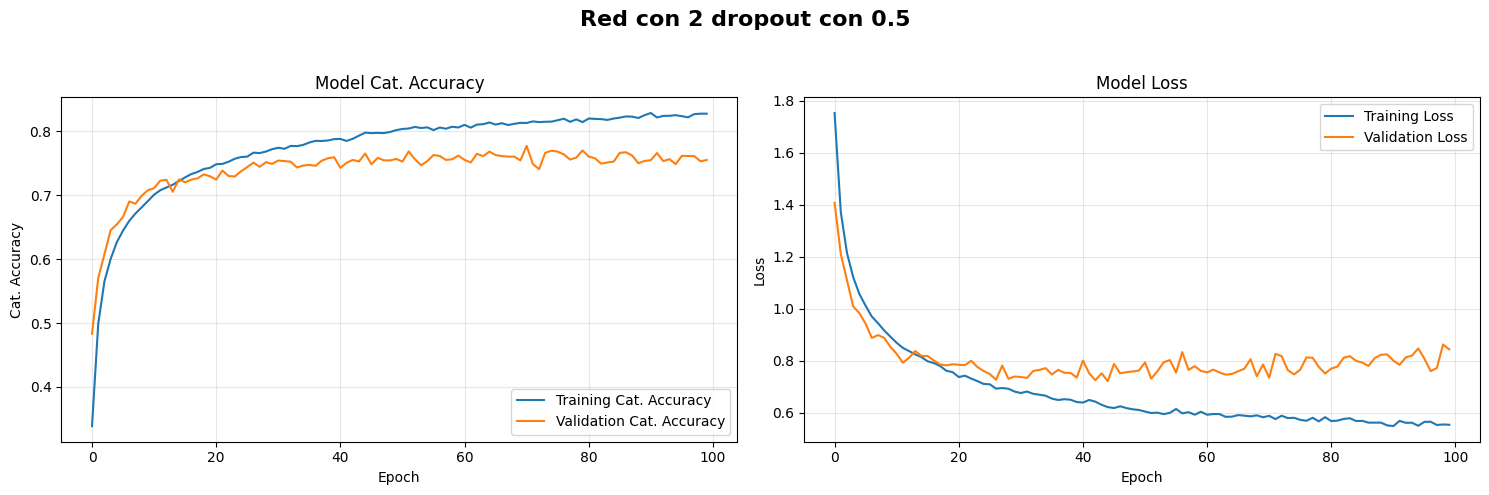

Resultados finales entrenamiento:
Training Accuracy: 0.8273
Validation Accuracy: 0.7550
Training Loss: 0.5531
Validation Loss: 0.8435

Best Validation Accuracy: 0.7770
Best Validation Loss: 0.7211


In [ ]:
plot_history_graphics(history4, red_drop2_2, "Red con 2 dropout con 0.5")

In [ ]:
imprimir_test(red_drop2_2, x_test, y_test)

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step

CNN Results:
Correct predictions: 7517/10000
Accuracy: 0.7517 (75.17%)
Error Rate: 0.2483 (24.83%)


**Conclusion**: Vemos que las redes con un dropout luego de la ultima capa convolucional tienen un error de test muy similar, lo cual significa que aplicar dropout mejora el rendimiento ya que evito realizar overfitting al apagar un numero no muy alto de neuronas. Aunque es un poco peor el dropout con probabilidad 0.5 pero esto puede deberse a caer un minimo local distinto.

Por otro lado, con dos dropout con probabilidad 0.2 vemos que el rendimiento de la red cae bastante pero vuelve a aumentar con probabilidad 0.5 aunque no llega al nivel de un solo dropout. Esto puede estar relacionado con que los dos dropout se apagan muchas neuronas y esto reduce la capacidad de aprender de la red. A su vez, en el caso de 2 dropout el rendimiento mejora con 0.5 porque la cantidad de neuronas apagadas con 0.2 no es sufuciente para evitar el overfitting y a su vez hace que la red tarde mas en aprender, mientras que al apagar mas neuronas evito el overfitting y puedo aprender mas.

# Ejercicio 3. Data Augmentation

Definimos la red con data augmentation

In [8]:
img_height = 32
img_width = 32
data_augmentation = keras.Sequential([
  layers.RandomFlip("horizontal", input_shape=(img_height, img_width, 3)),
  layers.RandomRotation(0.1),
  layers.RandomZoom(0.1),])

red_data = keras.Sequential([
    keras.Input(shape=(32, 32, 3), name='entrada'),

    data_augmentation,

    layers.Conv2D(32, (3, 3), padding='same', activation='relu', name='conv2d_1'),

    layers.Conv2D(32, (3, 3), padding='same', activation='relu', name='conv2d_2'),

    layers.MaxPooling2D((2, 2), name='maxpool2d_1'),

    layers.Conv2D(64, (3, 3), padding='same', activation='relu', name='conv2d_3'),

    layers.Conv2D(64, (3, 3), padding='same', activation='relu', name='conv2d_4'),

    layers.MaxPooling2D((2, 2), name='maxpool2d_2'),

    layers.Conv2D(64, (3, 3), padding='same', activation='relu', name='conv2d_5'),

    layers.Conv2D(64, (3, 3), padding='same', activation='relu', name='conv2d_6'),

    layers.MaxPooling2D((2, 2), name='maxpool2d_3'),

    layers.Dropout(0.2, name='dropout_1'),

    layers.Flatten(name='flatten'),

    layers.Dense(128, activation='relu', name='dense_1'),

    layers.Dense(64, activation='relu', name='dense_2'),

    layers.Dense(10, activation='softmax', name='salida')], name = "red_data_augmentation")

red_data.summary()

optimizer = keras.optimizers.Adam(learning_rate=0.001)

loss = keras.losses.CategoricalCrossentropy()

metrics = [keras.metrics.CategoricalAccuracy()]

red_data.compile(
  optimizer=optimizer,
  loss=loss,
  metrics=metrics)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/preprocessing/data_layer.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "red_data_augmentation"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ sequential (Sequential)         │ (None, 32, 32, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 32, 32, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 32, 32, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ maxpool2d_1 (MaxPooling2D)      │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 16, 16, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 16, 16, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ maxpool2d_2 (MaxPooling2D)      │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 8, 8, 64)       │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 8, 8, 64)       │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ maxpool2d_3 (MaxPooling2D)      │ (None, 4, 4, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 4, 4, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 1024)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │       131,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ salida (Dense)                  │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 279,530 (1.07 MB)

 Trainable params: 279,530 (1.07 MB)

 Non-trainable params: 0 (0.00 B)

Entrenamos la red

In [12]:
history_data = entrenar_red_dropout(red_data, "red_data")
from google.colab import drive
drive.mount('/content/drive')
red_data.save('/content/drive/MyDrive/tp4_red_data.keras')


Starting red_data training...
Epoch 1/100
2813/2813 ━━━━━━━━━━━━━━━━━━━━ 39s 11ms/step - categorical_accuracy: 0.3640 - loss: 1.7295 - val_categorical_accuracy: 0.4634 - val_loss: 1.4537
Epoch 2/100
2813/2813 ━━━━━━━━━━━━━━━━━━━━ 29s 10ms/step - categorical_accuracy: 0.4910 - loss: 1.4028 - val_categorical_accuracy: 0.5272 - val_loss: 1.3038
Epoch 3/100
2813/2813 ━━━━━━━━━━━━━━━━━━━━ 29s 10ms/step - categorical_accuracy: 0.5355 - loss: 1.2897 - val_categorical_accuracy: 0.5690 - val_loss: 1.2397
Epoch 4/100
2813/2813 ━━━━━━━━━━━━━━━━━━━━ 30s 11ms/step - categorical_accuracy: 0.5661 - loss: 1.2168 - val_categorical_accuracy: 0.5908 - val_loss: 1.1803
Epoch 5/100
2813/2813 ━━━━━━━━━━━━━━━━━━━━ 28s 10ms/step - categorical_accuracy: 0.5911 - loss: 1.1588 - val_categorical_accuracy: 0.6470 - val_loss: 1.0118
Epoch 6/100
2813/2813 ━━━━━━━━━━━━━━━━━━━━ 29s 10ms/step - categorical_accuracy: 0.6083 - loss: 1.1136 - val_categorical_accuracy: 0.5810 - val_loss: 1.2176
Epoch 7/100
2813/2813 ━━━━━

ValueError: mount failed

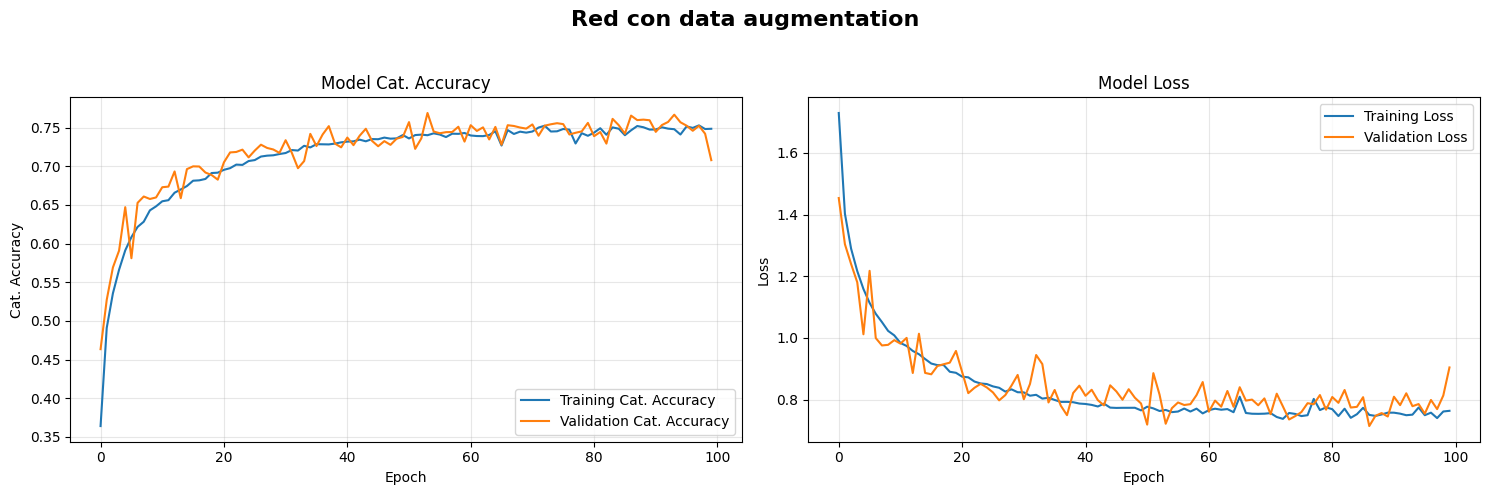

Resultados finales entrenamiento:
Training Accuracy: 0.7484
Validation Accuracy: 0.7078
Training Loss: 0.7636
Validation Loss: 0.9042

Best Validation Accuracy: 0.7688
Best Validation Loss: 0.7141


In [13]:
plot_history_graphics(history_data, red_data, "Red con data augmentation")

In [14]:
imprimir_test(red_data, x_test, y_test)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step

CNN Results:
Correct predictions: 7007/10000
Accuracy: 0.7007 (70.07%)
Error Rate: 0.2993 (29.93%)


**Conclusion**: Vemos que los resultados son peores que con el dropout optimo, pero si vemos las graficas de accuracy podemos notar la red no realizo ningun sobreajuste sino que al contrario el accuracy del entrenamiento y validacion al finalizar son muy parecidos. A su vez, viendo el proceso de entrenamiento se puede apreciar en la evolucion del accuracy del entranamiento y validacion, que estas van mejorando epoca a epoca pero muy lentamente contrario a lo que pasaba en otros modelos donde el accuracy de entranamiento llegaba muy rapidamente a superar el 90% y con ello caia la validacion fuertemente, pero en este caso el accuracy de entrenamiento no llega al 90% por lo tanto red no overfittea. Por lo tanto creo que la red podria mejorar su rendimiento con un numero mayor de epocas y esto puede deberse a que aunque aumente las epocas a la misma cantidad que para entrenar con dropout, al tener mayor cantidad de imagenes por la capa de data augmentation entonces la red necesita un mayor numero de epocas para aprender ya que al modificar las imagenes evito que haga trampa y simplemente memorize para que en su lugar aprenda de verdad.

# Ejercicio 4. Transfer Learning

Definimos la red

In [15]:
from google.colab import drive
drive.mount('/content/drive')

red_transfer = keras.Sequential([
    keras.Input(shape=(32, 32, 3), name='entrada'),

    layers.Conv2D(32, (3, 3), padding='same', activation='relu', name='conv2d_1'),

    layers.MaxPooling2D((2, 2), name='maxpool2d_1'),

    layers.Conv2D(64, (3, 3), padding='same', activation='relu', name='conv2d_2'),

    layers.Conv2D(64, (3, 3), padding='same', activation='relu', name='conv2d_3'),

    layers.MaxPooling2D((2, 2), name='maxpool2d_2'),

    layers.Conv2D(64, (3, 3), padding='same', activation='relu', name='conv2d_4'),

    layers.Conv2D(64, (3, 3), padding='same', activation='relu', name='conv2d_5'),

    layers.Flatten(name='flatten'),

    layers.Dense(64, activation='relu', name='dense_1'),

    layers.Dense(128, activation='relu', name='dense_2'),

    layers.Dense(128, activation='relu', name='dense_3'),

    layers.Dense(8, activation='softmax', name='salida')], name = 'red_transfer')

red_transfer.summary()

# defino los parametros de la red
optimizer = keras.optimizers.Adam(learning_rate=0.001)

loss = keras.losses.CategoricalCrossentropy()

metrics = [keras.metrics.CategoricalAccuracy()]

red_transfer.compile(
    optimizer=optimizer,
    loss=loss,
    metrics=metrics
)

Mounted at /content/drive


Model: "red_transfer"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_1 (Conv2D)               │ (None, 32, 32, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ maxpool2d_1 (MaxPooling2D)      │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 16, 16, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 16, 16, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ maxpool2d_2 (MaxPooling2D)      │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 8, 8, 64)       │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 8, 8, 64)       │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 4096)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │       262,208 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │         8,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ salida (Dense)                  │ (None, 8)              │         1,032 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 418,248 (1.60 MB)

 Trainable params: 418,248 (1.60 MB)

 Non-trainable params: 0 (0.00 B)

Preparamos los datos para el entrenamiento

In [16]:
# nos quedamos con ejemplos de 8 clases
x_train_8 = x_train[y_train.flatten() < 8]
y_train_8 = y_train[y_train.flatten() < 8]
print(f"Training data shape: {x_train_8.shape}")
print(f"Training labels shape: {y_train_8.shape}")

x_test_8  = x_test[y_test.flatten() < 8]
y_test_8  = y_test[y_test.flatten() < 8]
print(f"Test data shape: {x_train_8.shape}")
print(f"Test labels shape: {y_train_8.shape}")

num_classes = 8

y_train_8_onehot = keras.utils.to_categorical(y_train_8, num_classes)
y_test_8_onehot = keras.utils.to_categorical(y_test_8, num_classes)

x_train_processed_8, x_val_processed_8, y_train_processed_8, y_val_processed_8 = \
    train_test_split(x_train_8, y_train_8_onehot, test_size=0.1, stratify=y_train_8)

# nos aseguramos que nos perdemos datos
assert(x_train_processed_8.shape[0] + x_val_processed_8.shape[0] == x_train_8.shape[0])
assert(y_train_processed_8.shape[0] + y_val_processed_8.shape[0] == y_train_8.shape[0])

Training data shape: (40000, 32, 32, 3)
Training labels shape: (40000,)
Test data shape: (40000, 32, 32, 3)
Test labels shape: (40000,)


Entrenamos la red

In [17]:
print("\nStarting red transfer training...")
history_t1 = red_transfer.fit(
    x_train_processed_8, y_train_processed_8,
    batch_size=16,
    epochs=50,
    validation_data=(x_val_processed_8, y_val_processed_8),
    verbose=1,
)
print("\nred transfer training completed!")


Starting red transfer training...
Epoch 1/50
2250/2250 ━━━━━━━━━━━━━━━━━━━━ 16s 5ms/step - categorical_accuracy: 0.3533 - loss: 1.6542 - val_categorical_accuracy: 0.4918 - val_loss: 1.3728
Epoch 2/50
2250/2250 ━━━━━━━━━━━━━━━━━━━━ 17s 5ms/step - categorical_accuracy: 0.5503 - loss: 1.2223 - val_categorical_accuracy: 0.5960 - val_loss: 1.1000
Epoch 3/50
2250/2250 ━━━━━━━━━━━━━━━━━━━━ 12s 5ms/step - categorical_accuracy: 0.6111 - loss: 1.0589 - val_categorical_accuracy: 0.5960 - val_loss: 1.0947
Epoch 4/50
2250/2250 ━━━━━━━━━━━━━━━━━━━━ 11s 5ms/step - categorical_accuracy: 0.6551 - loss: 0.9469 - val_categorical_accuracy: 0.6653 - val_loss: 0.9335
Epoch 5/50
2250/2250 ━━━━━━━━━━━━━━━━━━━━ 9s 4ms/step - categorical_accuracy: 0.6958 - loss: 0.8509 - val_categorical_accuracy: 0.6565 - val_loss: 0.9525
Epoch 6/50
2250/2250 ━━━━━━━━━━━━━━━━━━━━ 12s 5ms/step - categorical_accuracy: 0.7196 - loss: 0.7802 - val_categorical_accuracy: 0.6817 - val_loss: 0.8977
Epoch 7/50
2250/2250 ━━━━━━━━━━━━━━━

Preparamos la red para clasificar las 2 clases restantes

In [51]:
red_transfer.pop()
for layer in red_transfer.layers:
  layer.trainable = False

red_transfer2 = keras.Sequential([
  red_transfer,
  layers.Dense(2, activation='softmax') ])

red_transfer2.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.001),
    loss=keras.losses.CategoricalCrossentropy(),
    metrics=[keras.metrics.CategoricalAccuracy()]
)

Preparamos los datos

In [19]:
x_train_2 = x_train[y_train.flatten() >= 8]
y_train_2 = y_train[y_train.flatten() >= 8]

x_test_2  = x_test[y_test.flatten() >= 8]
y_test_2  = y_test[y_test.flatten() >= 8]

x_train_2 = x_train_2.astype('float32') / 255.0
x_test_2 = x_test_2.astype('float32') / 255.0

y_train_2_mapped = y_train_2 - 8
y_test_2_mapped = y_test_2 - 8

num_classes_2 = 2
y_train_2_onehot = keras.utils.to_categorical(y_train_2_mapped, num_classes_2)
y_test_2_onehot = keras.utils.to_categorical(y_test_2_mapped, num_classes_2)

x_train_processed_2, x_val_processed_2, y_train_processed_2, y_val_processed_2 = \
    train_test_split(x_train_2, y_train_2_onehot, test_size=0.1, stratify=y_train_2_mapped)

In [20]:
print("\nStarting red transfer 2 training...")
history_t2 = red_transfer2.fit(
    x_train_processed_2, y_train_processed_2,
    batch_size=16,
    epochs=20,
    validation_data=(x_val_processed_2, y_val_processed_2),
    verbose=1
)
print("\nrred transfer 2 training completed!")
red_transfer2.save('/content/drive/MyDrive/tp4_red_transfer2.keras')


Starting red transfer 2 training...
Epoch 1/20
563/563 ━━━━━━━━━━━━━━━━━━━━ 7s 10ms/step - categorical_accuracy: 0.5648 - loss: 0.8531 - val_categorical_accuracy: 0.5960 - val_loss: 0.6669
Epoch 2/20
563/563 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - categorical_accuracy: 0.5766 - loss: 0.6771 - val_categorical_accuracy: 0.5980 - val_loss: 0.6657
Epoch 3/20
563/563 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - categorical_accuracy: 0.5802 - loss: 0.6750 - val_categorical_accuracy: 0.5980 - val_loss: 0.6633
Epoch 4/20
563/563 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - categorical_accuracy: 0.5802 - loss: 0.6737 - val_categorical_accuracy: 0.6340 - val_loss: 0.6583
Epoch 5/20
563/563 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - categorical_accuracy: 0.5853 - loss: 0.6728 - val_categorical_accuracy: 0.6340 - val_loss: 0.6577
Epoch 6/20
563/563 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - categorical_accuracy: 0.5898 - loss: 0.6696 - val_categorical_accuracy: 0.6360 - val_loss: 0.6534
Epoch 7/20
563/563 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/ste

Testeamos los resultados

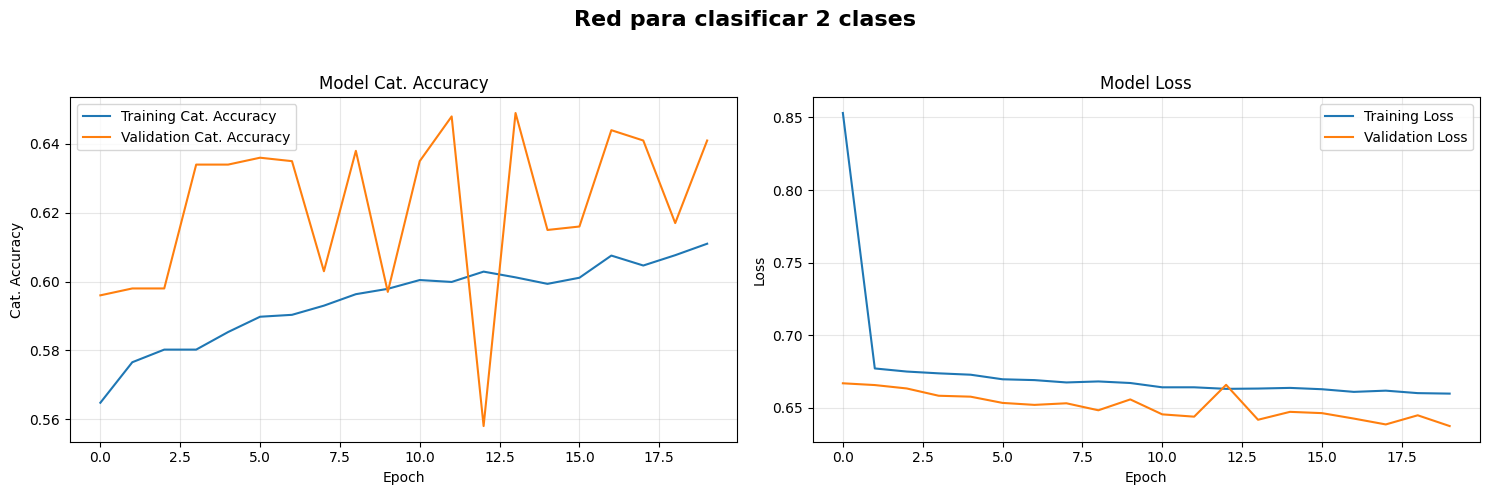

Resultados finales entrenamiento:
Training Accuracy: 0.6110
Validation Accuracy: 0.6410
Training Loss: 0.6598
Validation Loss: 0.6374

Best Validation Accuracy: 0.6490
Best Validation Loss: 0.6374


In [21]:
plot_history_graphics(history_t2, red_transfer2, "Red para clasificar 2 clases")

In [27]:
imprimir_test(red_transfer2, x_test_2, y_test_2_mapped)

63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step

CNN Results:
Correct predictions: 1514/2000
Accuracy: 0.7570 (75.70%)
Error Rate: 0.2430 (24.30%)


Vamos descongelar capas y volvemos a entrenar

In [28]:
# capas entrenables
red_transfer2.summary(show_trainable=True)

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━┓
┃ Layer (type)                ┃ Output Shape          ┃    Param # ┃ Trai… ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━┩
│ red_transfer (Sequential)   │ (None, 128)           │    417,216 │   Y   │
├─────────────────────────────┼───────────────────────┼────────────┼───────┤
│ dense (Dense)               │ (None, 2)             │        258 │   Y   │
└─────────────────────────────┴───────────────────────┴────────────┴───────┘

 Total params: 992,072 (3.78 MB)

 Trainable params: 287,298 (1.10 MB)

 Non-trainable params: 130,176 (508.50 KB)

 Optimizer params: 574,598 (2.19 MB)

In [24]:
# funcion para entrenar la red
def entrenar_transfer(red, nombre, epocas):
  print(f"\nStarting {nombre} training...")
  history = red.fit(
      x_train_processed_2, y_train_processed_2,
      batch_size=16,
      epochs=epocas,
      validation_data=(x_val_processed_2, y_val_processed_2),
      verbose=1
  )
  print(f"\n{nombre} training completed!")
  return history

Descongelamos las capas densas

In [29]:
for layer in red_transfer.layers[-3:]:
    layer.trainable = True

red_transfer2.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.0001),
    loss=keras.losses.CategoricalCrossentropy(),
    metrics=[keras.metrics.CategoricalAccuracy()]
)
red_transfer.summary(show_trainable=True)
history_descongelado1 = entrenar_transfer(red_transfer2, "Red con las capas densas descongelada", 20)

Model: "red_transfer"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━┓
┃ Layer (type)                ┃ Output Shape          ┃    Param # ┃ Trai… ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━┩
│ conv2d_1 (Conv2D)           │ (None, 32, 32, 32)    │        896 │   N   │
├─────────────────────────────┼───────────────────────┼────────────┼───────┤
│ maxpool2d_1 (MaxPooling2D)  │ (None, 16, 16, 32)    │          0 │   -   │
├─────────────────────────────┼───────────────────────┼────────────┼───────┤
│ conv2d_2 (Conv2D)           │ (None, 16, 16, 64)    │     18,496 │   N   │
├─────────────────────────────┼───────────────────────┼────────────┼───────┤
│ conv2d_3 (Conv2D)           │ (None, 16, 16, 64)    │     36,928 │   N   │
├─────────────────────────────┼───────────────────────┼────────────┼───────┤
│ maxpool2d_2 (MaxPooling2D)  │ (None, 8, 8, 64)      │          0 │   -   │
├─────────────────────────────┼───────────────────────┼────────────┼───────┤
│ conv2d_4 (Conv2D)           │ (None, 8, 8, 64)      │     36,928 │   N   │
├─────────────────────────────┼───────────────────────┼────────────┼───────┤
│ conv2d_5 (Conv2D)           │ (None, 8, 8, 64)      │     36,928 │   N   │
├─────────────────────────────┼───────────────────────┼────────────┼───────┤
│ flatten (Flatten)           │ (None, 4096)          │          0 │   -   │
├─────────────────────────────┼───────────────────────┼────────────┼───────┤
│ dense_1 (Dense)             │ (None, 64)            │    262,208 │   Y   │
├─────────────────────────────┼───────────────────────┼────────────┼───────┤
│ dense_2 (Dense)             │ (None, 128)           │      8,320 │   Y   │
├─────────────────────────────┼───────────────────────┼────────────┼───────┤
│ dense_3 (Dense)             │ (None, 128)           │     16,512 │   Y   │
└─────────────────────────────┴───────────────────────┴────────────┴───────┘

 Total params: 1,253,714 (4.78 MB)

 Trainable params: 287,040 (1.09 MB)

 Non-trainable params: 130,176 (508.50 KB)

 Optimizer params: 836,498 (3.19 MB)


Starting Red con las capas densas descongelada training...
Epoch 1/20
563/563 ━━━━━━━━━━━━━━━━━━━━ 6s 7ms/step - categorical_accuracy: 0.7337 - loss: 0.5484 - val_categorical_accuracy: 0.7670 - val_loss: 0.5194
Epoch 2/20
563/563 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - categorical_accuracy: 0.7467 - loss: 0.5349 - val_categorical_accuracy: 0.7430 - val_loss: 0.5305
Epoch 3/20
563/563 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - categorical_accuracy: 0.7346 - loss: 0.5393 - val_categorical_accuracy: 0.7800 - val_loss: 0.5046
Epoch 4/20
563/563 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - categorical_accuracy: 0.7361 - loss: 0.5388 - val_categorical_accuracy: 0.7010 - val_loss: 0.5594
Epoch 5/20
563/563 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - categorical_accuracy: 0.7391 - loss: 0.5371 - val_categorical_accuracy: 0.7650 - val_loss: 0.5050
Epoch 6/20
563/563 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - categorical_accuracy: 0.7462 - loss: 0.5292 - val_categorical_accuracy: 0.6430 - val_loss: 0.6181
Epoch 7/20
563/563 ━━━━━━━━━

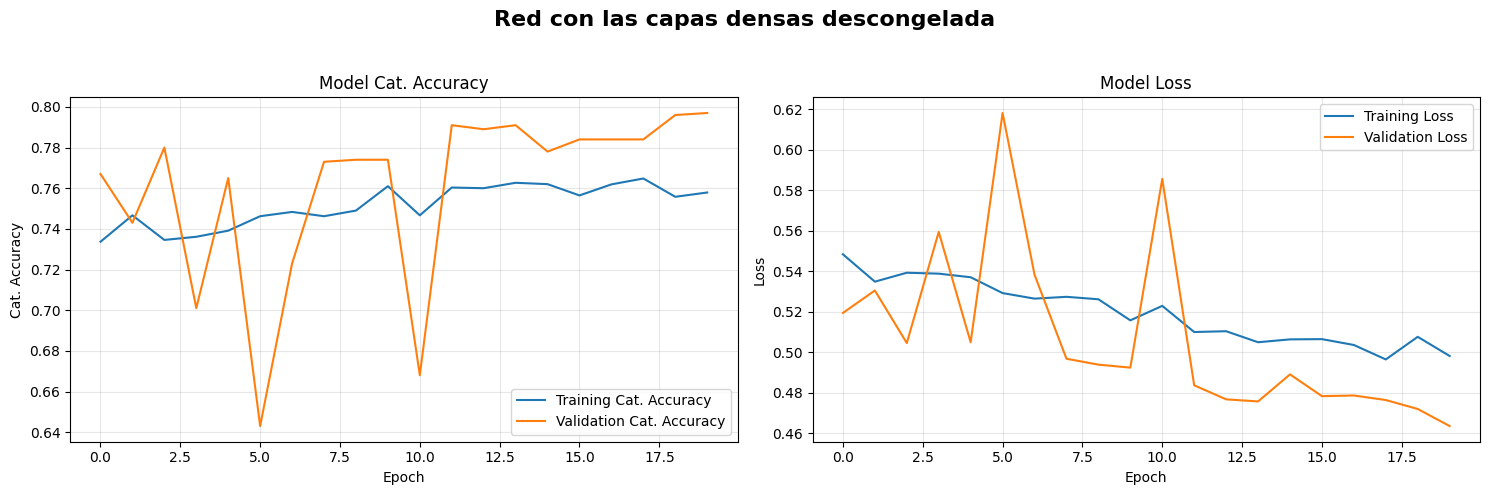

Resultados finales entrenamiento:
Training Accuracy: 0.7579
Validation Accuracy: 0.7970
Training Loss: 0.4982
Validation Loss: 0.4636

Best Validation Accuracy: 0.7970
Best Validation Loss: 0.4636


In [30]:
plot_history_graphics(history_descongelado1, red_transfer2, "Red con las capas densas descongelada")

In [31]:
imprimir_test(red_transfer2, x_test_2, y_test_2_mapped)

63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step

CNN Results:
Correct predictions: 1583/2000
Accuracy: 0.7915 (79.15%)
Error Rate: 0.2085 (20.85%)


Descongelamos hasta la ultima convolucion

In [52]:
for layer in red_transfer.layers[-6:]:
    layer.trainable = True

red_transfer2.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.0001),
    loss=keras.losses.CategoricalCrossentropy(),
    metrics=[keras.metrics.CategoricalAccuracy()]
)
red_transfer.summary(show_trainable=True)
history_descongelado1 = entrenar_transfer(red_transfer2, "Red hasta la ultima convolucion descongelada", 20)

Model: "red_transfer"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━┓
┃ Layer (type)                ┃ Output Shape          ┃    Param # ┃ Trai… ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━┩
│ conv2d_1 (Conv2D)           │ (None, 32, 32, 32)    │        896 │   N   │
├─────────────────────────────┼───────────────────────┼────────────┼───────┤
│ maxpool2d_1 (MaxPooling2D)  │ (None, 16, 16, 32)    │          0 │   -   │
├─────────────────────────────┼───────────────────────┼────────────┼───────┤
│ conv2d_2 (Conv2D)           │ (None, 16, 16, 64)    │     18,496 │   N   │
├─────────────────────────────┼───────────────────────┼────────────┼───────┤
│ conv2d_3 (Conv2D)           │ (None, 16, 16, 64)    │     36,928 │   N   │
├─────────────────────────────┼───────────────────────┼────────────┼───────┤
│ maxpool2d_2 (MaxPooling2D)  │ (None, 8, 8, 64)      │          0 │   -   │
├─────────────────────────────┼───────────────────────┼────────────┼───────┤
│ conv2d_4 (Conv2D)           │ (None, 8, 8, 64)      │     36,928 │   Y   │
├─────────────────────────────┼───────────────────────┼────────────┼───────┤
│ conv2d_5 (Conv2D)           │ (None, 8, 8, 64)      │     36,928 │   Y   │
├─────────────────────────────┼───────────────────────┼────────────┼───────┤
│ flatten (Flatten)           │ (None, 4096)          │          0 │   -   │
├─────────────────────────────┼───────────────────────┼────────────┼───────┤
│ dense_1 (Dense)             │ (None, 64)            │    262,208 │   Y   │
├─────────────────────────────┼───────────────────────┼────────────┼───────┤
│ dense_2 (Dense)             │ (None, 128)           │      8,320 │   Y   │
└─────────────────────────────┴───────────────────────┴────────────┴───────┘

 Total params: 1,237,202 (4.72 MB)

 Trainable params: 344,384 (1.31 MB)

 Non-trainable params: 56,320 (220.00 KB)

 Optimizer params: 836,498 (3.19 MB)


Starting Red hasta la ultima convolucion descongelada training...
Epoch 1/20
563/563 ━━━━━━━━━━━━━━━━━━━━ 7s 8ms/step - categorical_accuracy: 0.7201 - loss: 1.8058 - val_categorical_accuracy: 0.8230 - val_loss: 0.4266
Epoch 2/20
563/563 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - categorical_accuracy: 0.8054 - loss: 0.4343 - val_categorical_accuracy: 0.8430 - val_loss: 0.3942
Epoch 3/20
563/563 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - categorical_accuracy: 0.8167 - loss: 0.4089 - val_categorical_accuracy: 0.8450 - val_loss: 0.3589
Epoch 4/20
563/563 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - categorical_accuracy: 0.8288 - loss: 0.3860 - val_categorical_accuracy: 0.8540 - val_loss: 0.3488
Epoch 5/20
563/563 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - categorical_accuracy: 0.8416 - loss: 0.3663 - val_categorical_accuracy: 0.8570 - val_loss: 0.3358
Epoch 6/20
563/563 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - categorical_accuracy: 0.8424 - loss: 0.3565 - val_categorical_accuracy: 0.8400 - val_loss: 0.3514
Epoch 7/20
563/563 ━━

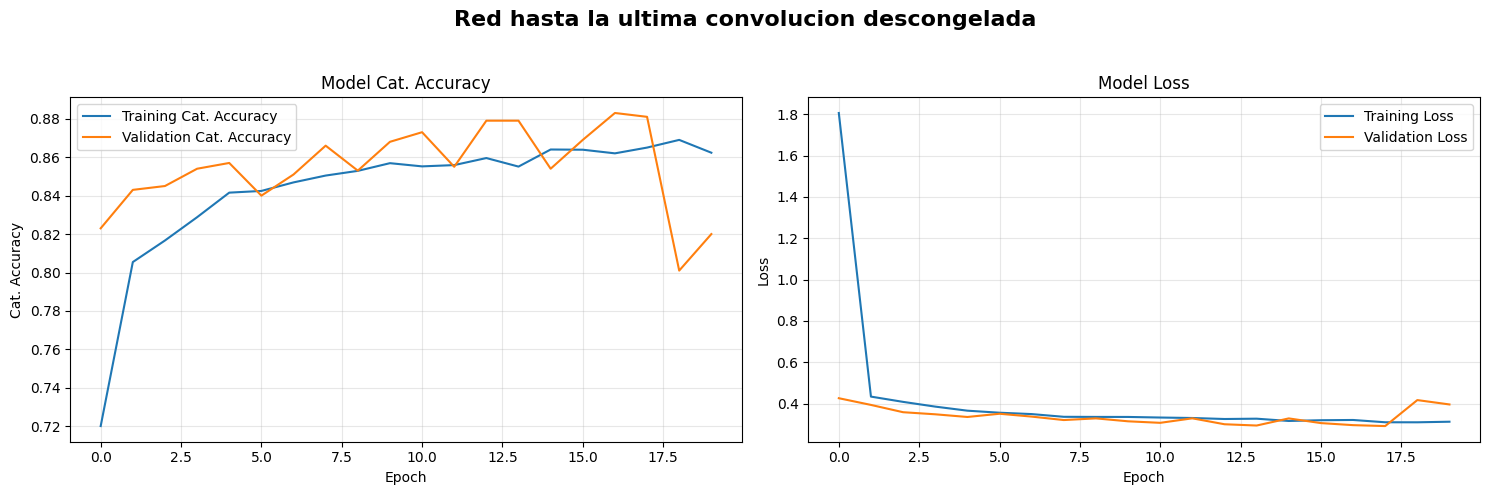

Resultados finales entrenamiento:
Training Accuracy: 0.8623
Validation Accuracy: 0.8200
Training Loss: 0.3129
Validation Loss: 0.3964

Best Validation Accuracy: 0.8830
Best Validation Loss: 0.2919


In [53]:
plot_history_graphics(history_descongelado1, red_transfer2, "Red hasta la ultima convolucion descongelada")

In [54]:
imprimir_test(red_transfer2, x_test_2, y_test_2_mapped)

63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step

CNN Results:
Correct predictions: 1607/2000
Accuracy: 0.8035 (80.35%)
Error Rate: 0.1965 (19.65%)


Descongelamos hasta la penultima convolucion

In [55]:
for layer in red_transfer.layers[-9:]:
    layer.trainable = True

red_transfer2.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.0001),
    loss=keras.losses.CategoricalCrossentropy(),
    metrics=[keras.metrics.CategoricalAccuracy()]
)
red_transfer.summary(show_trainable=True)
history_descongelado1 = entrenar_transfer(red_transfer2, "Red hasta la penultima convolucion descongelada", 20)

Model: "red_transfer"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━┓
┃ Layer (type)                ┃ Output Shape          ┃    Param # ┃ Trai… ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━┩
│ conv2d_1 (Conv2D)           │ (None, 32, 32, 32)    │        896 │   N   │
├─────────────────────────────┼───────────────────────┼────────────┼───────┤
│ maxpool2d_1 (MaxPooling2D)  │ (None, 16, 16, 32)    │          0 │   -   │
├─────────────────────────────┼───────────────────────┼────────────┼───────┤
│ conv2d_2 (Conv2D)           │ (None, 16, 16, 64)    │     18,496 │   Y   │
├─────────────────────────────┼───────────────────────┼────────────┼───────┤
│ conv2d_3 (Conv2D)           │ (None, 16, 16, 64)    │     36,928 │   Y   │
├─────────────────────────────┼───────────────────────┼────────────┼───────┤
│ maxpool2d_2 (MaxPooling2D)  │ (None, 8, 8, 64)      │          0 │   -   │
├─────────────────────────────┼───────────────────────┼────────────┼───────┤
│ conv2d_4 (Conv2D)           │ (None, 8, 8, 64)      │     36,928 │   Y   │
├─────────────────────────────┼───────────────────────┼────────────┼───────┤
│ conv2d_5 (Conv2D)           │ (None, 8, 8, 64)      │     36,928 │   Y   │
├─────────────────────────────┼───────────────────────┼────────────┼───────┤
│ flatten (Flatten)           │ (None, 4096)          │          0 │   -   │
├─────────────────────────────┼───────────────────────┼────────────┼───────┤
│ dense_1 (Dense)             │ (None, 64)            │    262,208 │   Y   │
├─────────────────────────────┼───────────────────────┼────────────┼───────┤
│ dense_2 (Dense)             │ (None, 128)           │      8,320 │   Y   │
└─────────────────────────────┴───────────────────────┴────────────┴───────┘

 Total params: 1,237,202 (4.72 MB)

 Trainable params: 399,808 (1.53 MB)

 Non-trainable params: 896 (3.50 KB)

 Optimizer params: 836,498 (3.19 MB)


Starting Red hasta la penultima convolucion descongelada training...
Epoch 1/20
563/563 ━━━━━━━━━━━━━━━━━━━━ 8s 8ms/step - categorical_accuracy: 0.8514 - loss: 0.3351 - val_categorical_accuracy: 0.8310 - val_loss: 0.3678
Epoch 2/20
563/563 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - categorical_accuracy: 0.8532 - loss: 0.3335 - val_categorical_accuracy: 0.8840 - val_loss: 0.2896
Epoch 3/20
563/563 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - categorical_accuracy: 0.8644 - loss: 0.3254 - val_categorical_accuracy: 0.8660 - val_loss: 0.3050
Epoch 4/20
563/563 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - categorical_accuracy: 0.8663 - loss: 0.3103 - val_categorical_accuracy: 0.8780 - val_loss: 0.2989
Epoch 5/20
563/563 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - categorical_accuracy: 0.8619 - loss: 0.3179 - val_categorical_accuracy: 0.8660 - val_loss: 0.3046
Epoch 6/20
563/563 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - categorical_accuracy: 0.8634 - loss: 0.3196 - val_categorical_accuracy: 0.8770 - val_loss: 0.3000
Epoch 7/20
563/563

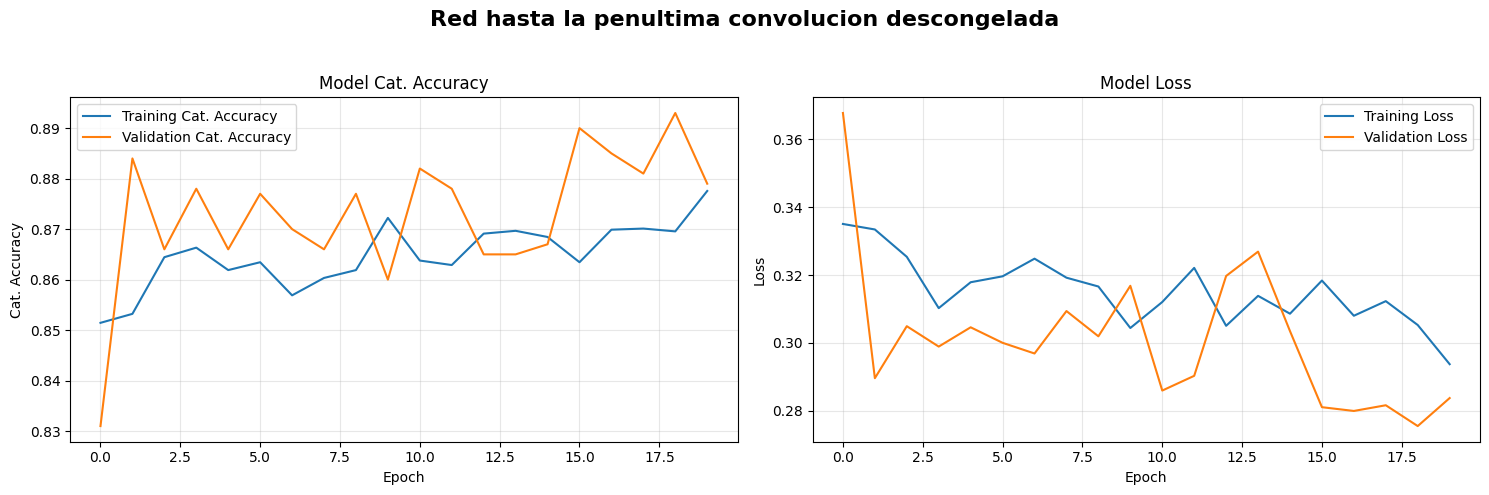

Resultados finales entrenamiento:
Training Accuracy: 0.8776
Validation Accuracy: 0.8790
Training Loss: 0.2938
Validation Loss: 0.2838

Best Validation Accuracy: 0.8930
Best Validation Loss: 0.2755


In [56]:
plot_history_graphics(history_descongelado1, red_transfer2, "Red hasta la penultima convolucion descongelada")

In [59]:
imprimir_test(red_transfer2, x_test_2, y_test_2_mapped)

63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step

CNN Results:
Correct predictions: 1757/2000
Accuracy: 0.8785 (87.85%)
Error Rate: 0.1215 (12.15%)


Descongelamos toda la red

In [60]:
for layer in red_transfer.layers[-11:]:
    layer.trainable = True

red_transfer2.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.0001),
    loss=keras.losses.CategoricalCrossentropy(),
    metrics=[keras.metrics.CategoricalAccuracy()]
)
red_transfer.summary(show_trainable=True)
history_descongelado1 = entrenar_transfer(red_transfer2, "Red descongelada", 20)

Model: "red_transfer"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━┓
┃ Layer (type)                ┃ Output Shape          ┃    Param # ┃ Trai… ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━┩
│ conv2d_1 (Conv2D)           │ (None, 32, 32, 32)    │        896 │   Y   │
├─────────────────────────────┼───────────────────────┼────────────┼───────┤
│ maxpool2d_1 (MaxPooling2D)  │ (None, 16, 16, 32)    │          0 │   -   │
├─────────────────────────────┼───────────────────────┼────────────┼───────┤
│ conv2d_2 (Conv2D)           │ (None, 16, 16, 64)    │     18,496 │   Y   │
├─────────────────────────────┼───────────────────────┼────────────┼───────┤
│ conv2d_3 (Conv2D)           │ (None, 16, 16, 64)    │     36,928 │   Y   │
├─────────────────────────────┼───────────────────────┼────────────┼───────┤
│ maxpool2d_2 (MaxPooling2D)  │ (None, 8, 8, 64)      │          0 │   -   │
├─────────────────────────────┼───────────────────────┼────────────┼───────┤
│ conv2d_4 (Conv2D)           │ (None, 8, 8, 64)      │     36,928 │   Y   │
├─────────────────────────────┼───────────────────────┼────────────┼───────┤
│ conv2d_5 (Conv2D)           │ (None, 8, 8, 64)      │     36,928 │   Y   │
├─────────────────────────────┼───────────────────────┼────────────┼───────┤
│ flatten (Flatten)           │ (None, 4096)          │          0 │   -   │
├─────────────────────────────┼───────────────────────┼────────────┼───────┤
│ dense_1 (Dense)             │ (None, 64)            │    262,208 │   Y   │
├─────────────────────────────┼───────────────────────┼────────────┼───────┤
│ dense_2 (Dense)             │ (None, 128)           │      8,320 │   Y   │
└─────────────────────────────┴───────────────────────┴────────────┴───────┘

 Total params: 1,237,202 (4.72 MB)

 Trainable params: 400,704 (1.53 MB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 836,498 (3.19 MB)


Starting Red descongelada training...
Epoch 1/20
563/563 ━━━━━━━━━━━━━━━━━━━━ 9s 9ms/step - categorical_accuracy: 0.8703 - loss: 0.3036 - val_categorical_accuracy: 0.8370 - val_loss: 0.3439
Epoch 2/20
563/563 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - categorical_accuracy: 0.8667 - loss: 0.3144 - val_categorical_accuracy: 0.8670 - val_loss: 0.3026
Epoch 3/20
563/563 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - categorical_accuracy: 0.8639 - loss: 0.3176 - val_categorical_accuracy: 0.8740 - val_loss: 0.3078
Epoch 4/20
563/563 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - categorical_accuracy: 0.8718 - loss: 0.3055 - val_categorical_accuracy: 0.8530 - val_loss: 0.3395
Epoch 5/20
563/563 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - categorical_accuracy: 0.8731 - loss: 0.2965 - val_categorical_accuracy: 0.8710 - val_loss: 0.3102
Epoch 6/20
563/563 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - categorical_accuracy: 0.8718 - loss: 0.3041 - val_categorical_accuracy: 0.8760 - val_loss: 0.2876
Epoch 7/20
563/563 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/st

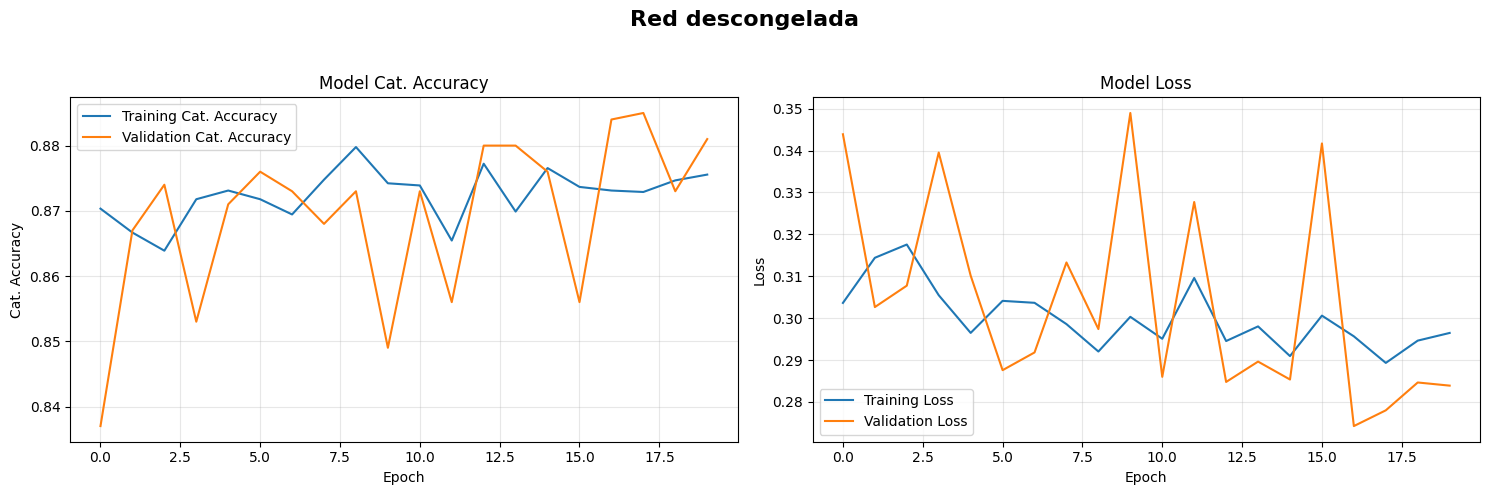

Resultados finales entrenamiento:
Training Accuracy: 0.8756
Validation Accuracy: 0.8810
Training Loss: 0.2965
Validation Loss: 0.2839

Best Validation Accuracy: 0.8850
Best Validation Loss: 0.2742


In [61]:
plot_history_graphics(history_descongelado1, red_transfer2, "Red descongelada")

In [62]:
imprimir_test(red_transfer2, x_test_2, y_test_2_mapped)

63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step

CNN Results:
Correct predictions: 1757/2000
Accuracy: 0.8785 (87.85%)
Error Rate: 0.1215 (12.15%)


**Conclusion**: Vemos que la red inicialmente al entrenarla para clasificar entre 8 clases y luego agregarle capa densa final para clasificar las nuevas dos clases tiene mejor accuracy de test que la red para clasificar con 10 clases, eso debe estar relacionado con el hecho de que es mucho mas facil clasificar entre imagenes de 2 clases que con 10.

Por otro lado, vemos que a medida que vamos descongenlando capas de la red para el entrenamiento el resultado del accuracy de test va mejorando, por ejemplo cuando descongelamos la capa densa conseguimos una mejora de hasta 4%, y cuando descongelamos hasta la ultima convolucion tambien la red mejora un 1% con respecto a solo descongelar las capas densas. Sin embargo, esta mejora sigue hasta que descongelamos toda la red, ahi vemos que llega al mismo rendimiento que al descongelar todo menos la ultima convolucion. Esto puede deberser a que el modelo ya llego a un minimo local bastante bueno. La mejora a medida que descongelamos las redes es que vamos aplicando fine-tunning que mejora el rendimiento le permite a la red que ya tiene una base aprender sobre a diferenciar y centrarse sobre esos nuevos ejemplos.